# Predicted TX spectrum

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import tx_model as tx
from tx_model import (FS_DAC, F_NCO, F_CARRIER, COMPARE_RATES, LFSR_TAPS,
                      mseq, rrc_taps, periodic_baseband, occupied_bw,
                      h_nrz, h_mix, board_loss_db, cw_ideal_dbm,
                      dac_output_lines, analyzer_trace, simulate, image_power,
                      plot_full_span, plot_chip_rate_compare, plot_fine_comb, print_summary)

Defining my usual plot appearance settings

In [2]:
plt.rcParams['font.size'] = '20';plt.rcParams['font.style'] = 'normal'
plt.rcParams['font.weight'] = 'normal';plt.rcParams['axes.grid'] = True;plt.rcParams['grid.linestyle'] = '-';
plt.rcParams['grid.linewidth'] = 0.4;plt.rcParams['grid.color'] = "Black";plt.rcParams['grid.alpha'] = 1;
plt.rcParams['lines.linewidth'] = 3;#plt.rcParams['axes.autolimit_mode'] = 'round_numbers';plt.rcParams['axes.axisbelow'] = True
plt.rcParams['xtick.direction'] = 'in';plt.rcParams['ytick.direction'] = 'in';plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 0.5;plt.rcParams['ytick.major.width'] = 1;plt.rcParams['ytick.minor.width'] = 0.5;
plt.rcParams['xtick.major.size'] = 4;plt.rcParams['xtick.minor.size'] = 2;plt.rcParams['ytick.major.size'] = 4;
plt.rcParams['ytick.minor.size'] = 2; plt.rcParams['svg.fonttype'] = 'none'; #cs = list(mcolors.TABLEAU_COLORS.values())
plt.rcParams['axes.linewidth']=1;plt.rcParams['xtick.top'] = True;plt.rcParams['ytick.right'] = True;
plt.rcParams['axes.spines.top'] = True;plt.rcParams['axes.spines.bottom'] = True;plt.rcParams['axes.spines.left'] = True;
plt.rcParams['axes.spines.right'] = True# Plot Appearance Settings

# FPGA Side

### 1. Linear Feedback Shift Register

In this cell, I simply call the mseq function, which runs the standard LFSR procedure to generate random number with a period of 2^n-1 for a n-bit register. In this case I am using 10 bits.

The register runs deterministically from there onwards based on a choice of two "taps" and an initial state (which I just set as an array of all 1s). These are whole numbers who represent the indices of the bits that will be XOR'd at each iteration.

That is all up to here.

length: 1023, ones: 512, zeros: 511, difference: 1


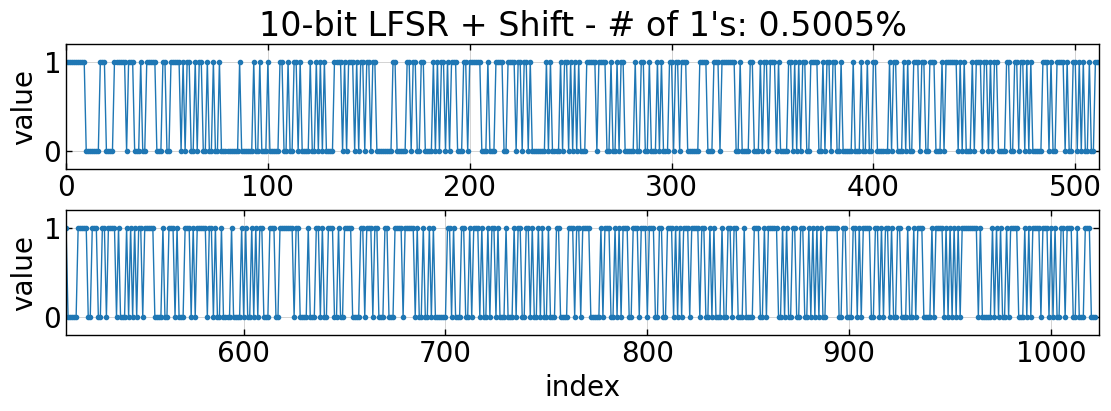

In [3]:
seq = mseq(10)
n_ones = int(np.count_nonzero(seq == 1))
n_zeros = int(np.count_nonzero(seq == 0))
print(f"length: {seq.size}, ones: {n_ones}, zeros: {n_zeros}, difference: {n_ones - n_zeros}")


fig, ax = plt.subplots(2, 1,figsize=(11, 4), layout = 'constrained')
ax[0].plot(seq, marker='o', ms=3, lw=1)
ax[0].set(ylabel="value",
       title=f"10-bit LFSR + Shift - # of 1's: {n_ones/(n_ones+n_zeros):.4f}%",
       xlim=(0, 512), ylim=(-0.2, 1.2))
ax[0].grid(alpha=0.3)
ax[1].plot(seq, marker='o', ms=3, lw=1)
ax[1].set(ylabel="value", xlabel='index',
       xlim=(512, 1024), ylim=(-0.2, 1.2))
ax[1].grid(alpha=0.3)

### 2. BPSK and Root-Raised-Cosine (RRC) Pulse Shaping

#### 2a. BPSK mapping and upsampling

* In this cell, I call on the same LFSR function as before (since it's deterministic, the output will be the same for the same choice of taps.)
* This array ("seq") is then shifted to turn 1->-1 and 0->1. The shifted array is called "up"
* "Up" is then turned into a new "chips" array, which is upsampled by the SPS (samples per chips)

Note that the chip rate $f_c$ relates to the DAC sampling rate $f_s$ (4.9152 GS/s) by:
$$
f_c=\frac{f_s}{N_s}
$$
So a specific choice of $N_s$ (number of samples per chips) will determine how many DAC sample periods to hold the current chip for before the next chip comes long. In the code I refere to this $N_S$ as SPS_DAC.

* Nevertheless, it makes sense to talk about a SPS_FGPA that is high enough to completely determine the frequencies in the signal $(f_{samp}> 2*f_{max})$ without unnecessarily adding computational cost.
* Although it can be chosen arbitrarily, from the start I assumed that a SPS_DAC of 96 would be reasonable, in that it will give a chip rate 51.2Mcps = 4.9152/96. This final effective chip rate will set the bandwidth of the resulting signal after the RRC filter to $(1+\beta)\times$ CHIP_RATE (69MHz if $\beta=0.35$). At this rate, the bandwidth is likely to fit completely within the amateur band of 5.725-5.850 GHz amateur band.
* Then I set SPS_FPGA to 8, which means the interpolation will add a factor of 12 in the sampling rate later. This is an integer fraction that is compatible with the RFSoC's operation.

But note that the CHIP_RATE is always the same. The Samples/Chip changes between stages and the effective Sample Rate changes correspondingly:

| Stage | Sample rate | Samples/chip | Chip rate = sample rate / samples per chip |
|---|---:|---:|---:|
| FPGA (pre-×12) | FS_DAC / 12 = 409.6 MS/s | 8 | 409.6 / 8 = **51.2 Mcps** |
| DAC (post-×12) | FS_DAC = 4915.2 MS/s | 96 | 4915.2 / 96 = **51.2 Mcps** |


So our signal will behave something like this:

* In the very beggining, the chips are one sample per chip, so sampling rate is 51.2 Mcps (design choice) $\rightarrow$ flat spectrum across $\pm$ 51.2/2=25.6 MHz.
* Upsample by zero-stuffing, raising the sample/chip rate from 1 to 8. Spectrum now extends to 8x $\pm$ 25.6MHz = $\pm$ 204.8. The extended space is filled by copies of the original spectrum every 51.2 MHz.
* To carry 51.2M chips per second, the smalles frequency you need is 25.6 MHz (Nyquist bandwidth)
* A brick-wall filter at 25.6MHz ($\beta$=0) could do the job. Instead the RRC filter avoids the sharp cut and, with a $\beta=0.35$ value, leads to a bandwidth of $(1+0.35)\times 51.2/2 = 35.6MHz$.
* So before the NCO, the signal has a bandwidth of about 35.6MHz centered on zero, represented by a sample rate of 409.6 MS/s at a Chip Rate of 51.2 Mcps.
* After the NCO (digital mixer), each sample is multiplied by a sample (at the DAC rate) of a 784.8 MHz cosine, as in
$$
y_{NCO}[n]=b[n]\times\cos\left(2\pi \times \frac{784.8 \text{MHz}}{4915.2 \text{MHz}} \times n\right)
$$

* After this step, the signal is now centered at 784.8 MHz. This is a frequency I choose for the NCO at the Jupyter notebook interface of the RFSoC.
* Just like before, any sampled signal at frequency f also has copies at every $k \times fs \pm f$. When the DAC turns the samples into an analog voltage, all of those copies are physically present at its output.

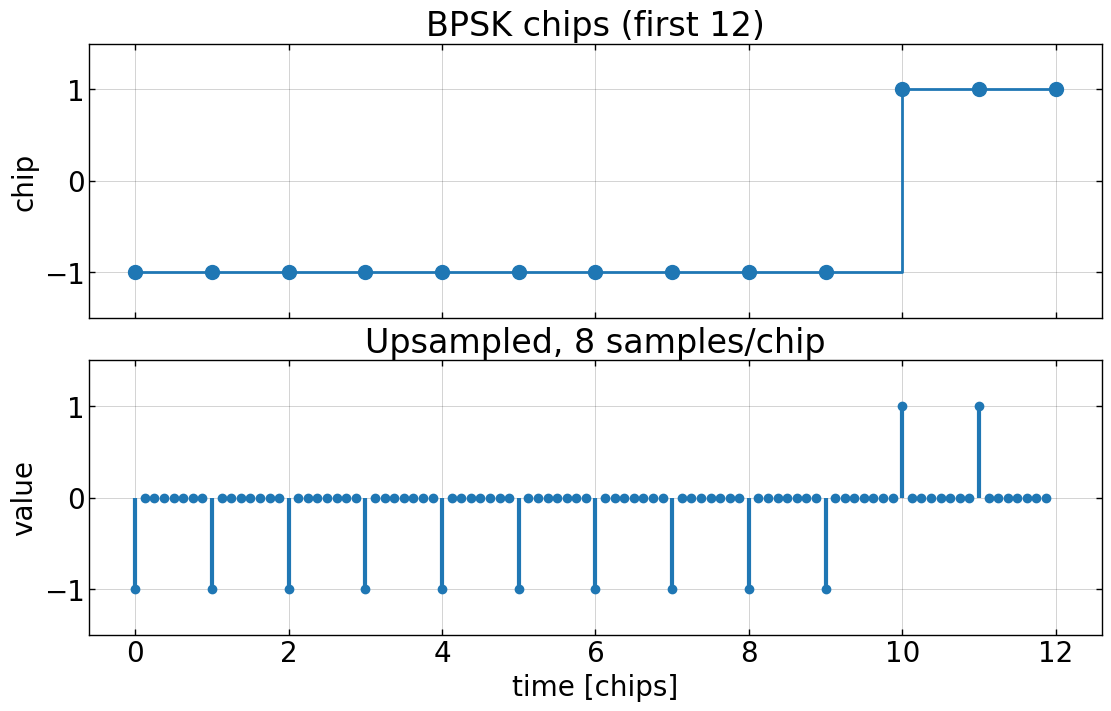

In [4]:
# Sampling rates
NBITS     = 10             # LFSR length; PRN period = 2^NBITS - 1 chips
SPS_DAC = 96
CHIP_RATE = FS_DAC / SPS_DAC    # chips/s (51.2 Mcps)
SPS_FPGA  = 8       # samples per chip
INTERP = SPS_DAC / SPS_FPGA



BETA      = 0.35           # RRC roll-off
PEAK_AMP  = 0.5            # waveform peak, same scale as DAC gain (0.5 = bench tone)
SPAN = 16     # RRC filter length in chips
N_SHOW = 12    # chips shown in the time-domain plots

fs_FPGA = SPS_FPGA * CHIP_RATE     # baseband sample rate
seq = mseq(NBITS)

chips = 1.0 - 2.0 * seq                   # 0 -> +1, 1 -> -1
up = np.zeros(chips.size * SPS_FPGA)
up[::SPS_FPGA] = chips                         # one chip every SPS samples, zeros between
n = np.arange(N_SHOW * SPS_FPGA)               # sample indices shown

fig, ax = plt.subplots(2, 1, figsize=(11, 7), layout='constrained', sharex=True)
ax[0].step(np.arange(N_SHOW + 1), np.append(chips[:N_SHOW], chips[N_SHOW - 1]), where="post", lw=2, ms=10, marker='o')
ax[0].set(ylabel="chip", title=f"BPSK chips (first {N_SHOW})", ylim=(-1.5, 1.5))
ax[0].grid(alpha=0.3)
ax[1].stem(n / SPS_FPGA, up[:N_SHOW * SPS_FPGA], basefmt=" ")
ax[1].set(ylabel="value", xlabel="time [chips]", title=f"Upsampled, {SPS_FPGA} samples/chip", ylim=(-1.5, 1.5))
ax[1].grid(alpha=0.3)

#### 2b. The RRC filter

Now the RRC filter can be thought of a real-world implementation of a "brick wall" filter that would constrain the "sinc"-like spectrum of the "square"-like wave of pseudo-random digits into a continuous signal that fits the intended communication spectrum.

The RRC filter is the square root of the raised-cosine spectrum:
$$
H_{RRC}(f)=\sqrt{H_{RC}(f)}
$$
Which is constructed in order to satisfy $h_{RC}(0)=1$ and $h_{RC}(kT)=0$ for every $k\neq0$. Where $T$ is the chip period (1/chip rate). The representation in the frequency domain is:
$$
H_{RC}(f)=
\begin{cases}
T, & |f| \le \dfrac{1-\beta}{2T} \\[10pt]
\dfrac{T}{2}\left[1 + \cos\!\left(\dfrac{\pi T}{\beta}\left(|f| - \dfrac{1-\beta}{2T}\right)\right)\right], & \dfrac{1-\beta}{2T} < |f| \le \dfrac{1+\beta}{2T} \\[10pt]
0, & |f| > \dfrac{1+\beta}{2T}
\end{cases}
$$

And the impulse response of the filter is
$$
h_{RC}(t) = \operatorname{sinc}\!\left(\frac{t}{T}\right)\frac{\cos\!\left(\pi\beta t/T\right)}{1 - \left(2\beta t/T\right)^{2}}
$$

Note that, on each side, the square root of the filter is the one that acts on the digital signal. Its impulse response is:

$$
h_{RRC}(t) = \frac{\sin\!\left(\pi \dfrac{t}{T}(1-\beta)\right) + 4\beta \dfrac{t}{T}\cos\!\left(\pi \dfrac{t}{T}(1+\beta)\right)}{\pi \dfrac{t}{T}\left[1 - \left(4\beta \dfrac{t}{T}\right)^{2}\right]}.
$$

Which does not yet satisfy the conditions we want. These require a second, matched, RC filter on the other side. Combine they act as an effective RRC filter.

$$
h_{RRC}(0) = 1 - \beta + \frac{4\beta}{\pi}
\qquad
h_{RRC}\!\left(\pm\frac{T}{4\beta}\right) = \frac{\beta}{\sqrt{2}}\left[\left(1+\frac{2}{\pi}\right)\sin\frac{\pi}{4\beta} + \left(1-\frac{2}{\pi}\right)\cos\frac{\pi}{4\beta}\right]
$$

Two points to understand here:
* The key result is that each chip's pulse is zero at the other chip's times - so zero intersymbol intereference. NOte that $T$ is a property of the signal, not of the filter.
* As mentioned above, the signal is sampled at a rate higher than the chip rate. In our case, we set SPS_FPGA = 8, so the $h(t)$ is evaluated every $T/8$ seconds, as in
$$
h(nT_s)=h\left(\frac{nT}{8}\right)
$$

band edges [MHz]: [16.64, 25.6, 34.56]


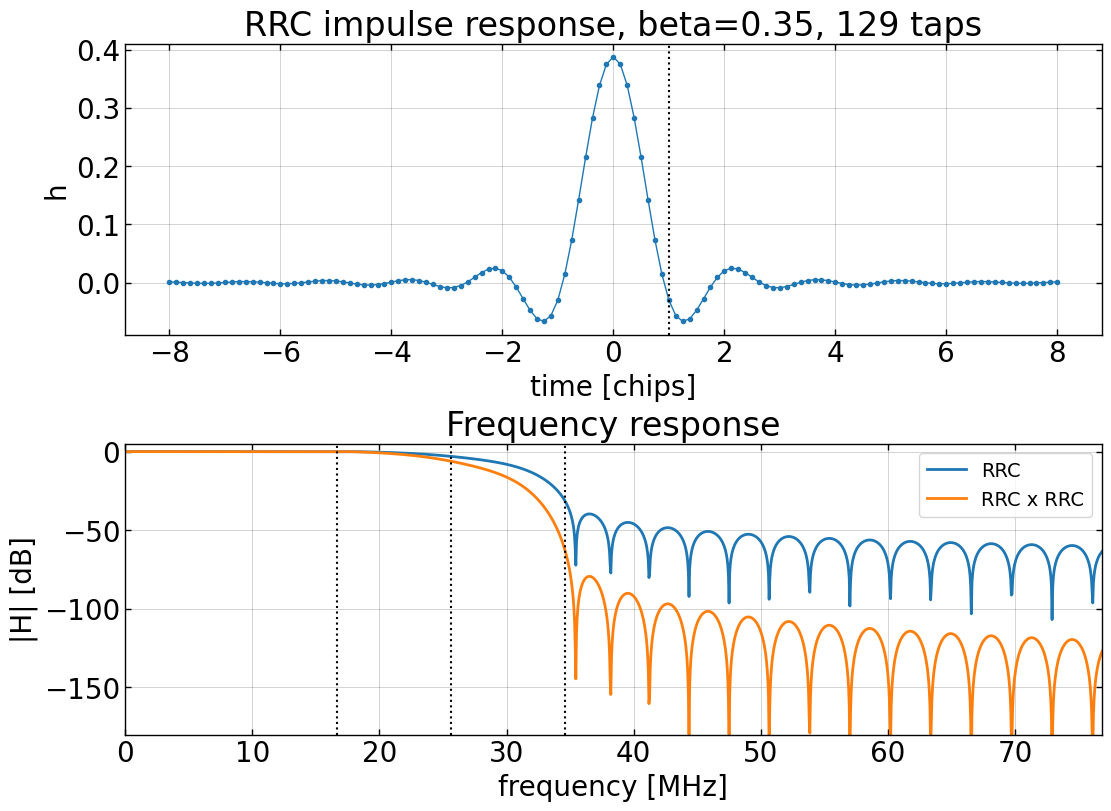

In [5]:
h = rrc_taps(BETA, SPS_FPGA, SPAN) # This function directly implements the equation I wrote above in the time domain
th = (np.arange(h.size) - h.size // 2) / SPS_FPGA          # time in chips, centered on 0

NFFT = 8192
f = np.fft.fftshift(np.fft.fftfreq(NFFT, 1 / fs_FPGA)) #the shift here is just reordering for display, otherwise numpy will put the negative frequencies at the end. Building the x axis labels for the 8192 fft bins
H = np.fft.fftshift(np.abs(np.fft.fft(h, NFFT))) #magntiude and reordering for display
H /= H.max()
edges = [(1 - BETA) * CHIP_RATE / 2, CHIP_RATE / 2, (1 + BETA) * CHIP_RATE / 2]
print("band edges [MHz]:", [round(e / 1e6, 2) for e in edges])

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(th, h, marker='o', ms=3, lw=1)
ax[0].set(xlabel="time [chips]", ylabel="h", title=f"RRC impulse response, beta={BETA}, {h.size} taps")
ax[0].grid(alpha=0.3)
ax[0].axvline(1, color="k", ls=":", lw=1.5)

ax[1].plot(f / 1e6, 20 * np.log10(H + 1e-12), lw=2, label="RRC") #just the fourier transform
ax[1].plot(f / 1e6, 20 * np.log10(H ** 2 + 1e-12), lw=2, label="RRC x RRC")
for e in edges:
    ax[1].axvline(e / 1e6, color="k", ls=":", lw=1.5)
ax[1].set(xlabel="frequency [MHz]", ylabel="|H| [dB]", title="Frequency response",
          xlim=(0, 1.5 * CHIP_RATE / 1e6), ylim=(-180, 5))
ax[1].legend(fontsize=14); ax[1].grid(alpha=0.3)

#### 2c. Filtering the chips

Circular convolution, because the PRN repeats with no gaps. The filter delays the signal by half its length; that is undone so the pulses line up with the chips.
Top: at the chip instants (dots) the values wander around ±0.3. That is ISI from the TX filter alone.
Bottom: spectrum before (flat impulses) and after (confined to ±Rc(1+β)/2).

occupied BW ~ Rc(1+beta) = 69.1 MHz
matches periodic_baseband: True


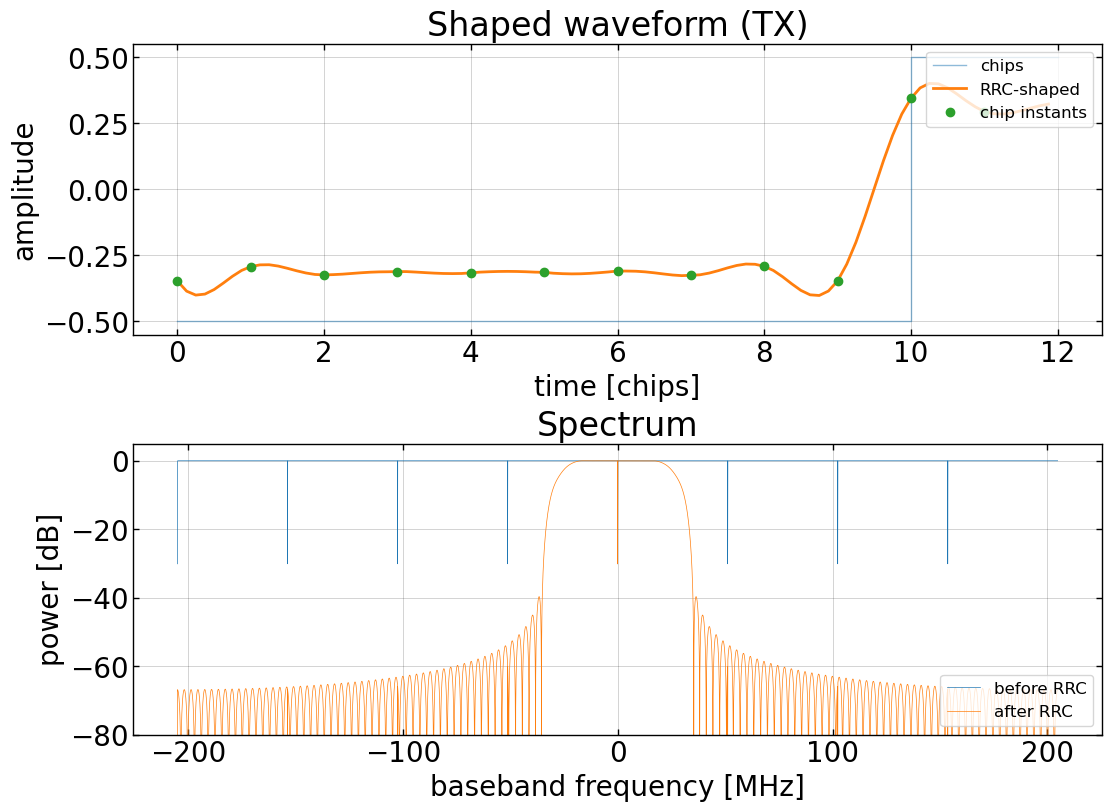

In [6]:
shaped = np.real(np.fft.ifft(np.fft.fft(up) * np.fft.fft(h, up.size))) #multiply the upsampled array by the RRC filter in the frequency domain
# remember that FFT bin k  ↔  frequency  k × fs / N        (k = 0 … N−1)
#up:  8184 samples  →  fft gives 8184 frequencies, spaced 409.6 MHz / 8184 = 50.05 kHz
#h:    129 taps     →  fft gives  129 frequencies, spaced 409.6 MHz / 129  = 3.18 MHz
#np.fft.fft(h, up.size) appends 8055 zeros to h before the FFT:
delay = h.size // 2                                   # filter delay in samples (half the taps)
shaped = np.roll(shaped, -delay)                      # undo the delay so chips line up
shaped *= PEAK_AMP / np.max(np.abs(shaped))           # same peak scaling as periodic_baseband

Pu = np.fft.fftshift(np.abs(np.fft.fft(up)) ** 2)
Ps = np.fft.fftshift(np.abs(np.fft.fft(shaped)) ** 2)
fu = np.fft.fftshift(np.fft.fftfreq(up.size, 1 / fs_FPGA))
print(f"occupied BW ~ Rc(1+beta) = {CHIP_RATE * (1 + BETA) / 1e6:.1f} MHz")

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].step(np.arange(N_SHOW + 1), PEAK_AMP * np.append(chips[:N_SHOW], chips[N_SHOW - 1]),
           where="post", lw=1, alpha=0.5, label="chips")
ax[0].plot(n / SPS_FPGA, shaped[:N_SHOW * SPS_FPGA], lw=2, label="RRC-shaped")
ax[0].plot(n[::SPS_FPGA] / SPS_FPGA, shaped[:N_SHOW * SPS_FPGA:SPS_FPGA], 'o', ms=6, label="chip instants")
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="Shaped waveform (TX)")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
ax[1].plot(fu / 1e6, 10 * np.log10(Pu / Pu.max() + 1e-15), lw=0.5, label="before RRC")
ax[1].plot(fu / 1e6, 10 * np.log10(Ps / Ps.max() + 1e-15), lw=0.5, label="after RRC")
ax[1].set(xlabel="baseband frequency [MHz]", ylabel="power [dB]", title="Spectrum", ylim=(-80, 5))
ax[1].legend(fontsize=12, loc="lower right"); ax[1].grid(alpha=0.3)

# check: same waveform as periodic_baseband(), up to the filter delay
b, _, _ = periodic_baseband(CHIP_RATE, BETA, nbits=NBITS, sps=SPS_FPGA, span=SPAN, peak_amp=PEAK_AMP)
print("matches periodic_baseband:", np.allclose(np.roll(b, -delay), shaped))

#### 2d. Eye diagrams: why RRC on both ends

Overlay 2-chip slices centered on each chip instant. After the TX RRC alone the eye is blurred (ISI).
After the RX matched RRC (RRC × RRC = raised cosine) every trace passes through ±1 at the chip instant: zero ISI.
The small leftover spread comes from truncating the filter to `SPAN` chips.

spread at chip instants: TX 0.666, RX 0.013


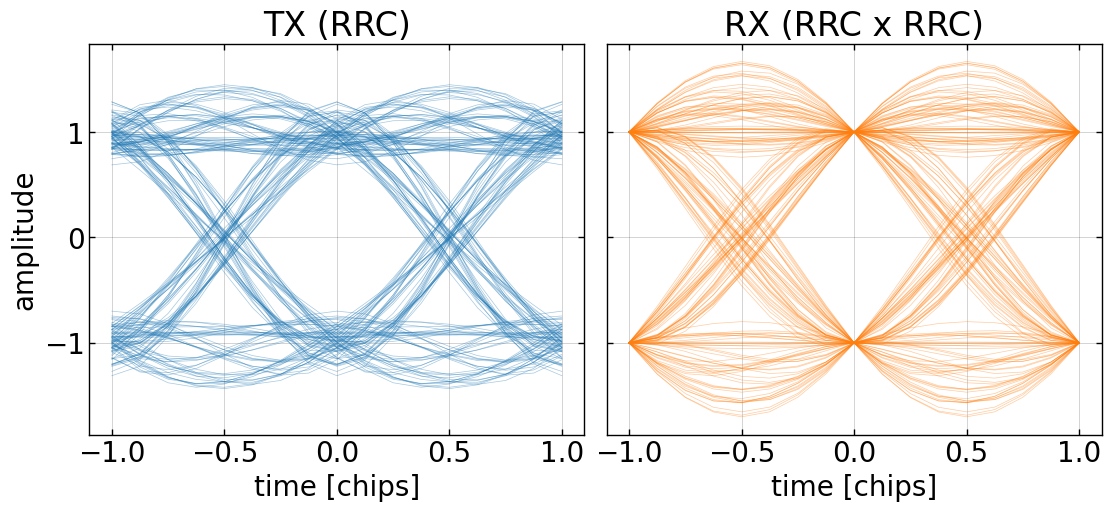

In [7]:
rx = np.real(np.fft.ifft(np.fft.fft(shaped) * np.fft.fft(h, shaped.size)))
rx = np.roll(rx, -delay)                              # undo the second filter delay
rx /= np.mean(np.abs(rx[::SPS_FPGA]))                      # normalize: chip instants at +/-1
tx_n = shaped / np.mean(np.abs(shaped[::SPS_FPGA]))
print(f"spread at chip instants: TX {np.ptp(np.abs(tx_n[::SPS_FPGA])):.3f}, RX {np.ptp(np.abs(rx[::SPS_FPGA])):.3f}")

te = np.arange(-SPS_FPGA, SPS_FPGA + 1) / SPS_FPGA                   # 2 chips wide, centered on a chip instant
fig, ax = plt.subplots(1, 2, figsize=(11, 5), layout='constrained', sharey=True)
for k in range(2, 200):
    i = k * SPS_FPGA
    ax[0].plot(te, tx_n[i - SPS_FPGA:i + SPS_FPGA + 1], "C0", lw=0.5, alpha=0.4)
    ax[1].plot(te, rx[i - SPS_FPGA:i + SPS_FPGA + 1], "C1", lw=0.5, alpha=0.4)
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="TX (RRC)")
ax[1].set(xlabel="time [chips]", title="RX (RRC x RRC)")
for a in ax:
    a.grid(alpha=0.3)

# DAC Side

### 3. Interpolation ×12: FPGA rate → DAC rate

The FPGA hands the RF Data Converter 8 samples per chip (409.6 MS/s). The DAC runs at 4.9152 GS/s, so the RF Data Converter's interpolation chain fills in 11 new samples between every pair of FPGA samples ($\times 12 \rightarrow$ 96 samples per chip). It is the same two-step recipe as 2a + 2c:

* **Zero-stuff by 12**: insert 11 zeros after every sample. The signal content does not change, but the spectrum now repeats every 409.6 MHz (copies at $k \times 409.6$ MHz $\pm$ 34.56 MHz) all the way up to the new Nyquist frequency $f_{s,DAC}/2 = 2457.6$ MHz.
* **Anti-imaging low-pass filter**: keep the copy at 0 Hz and remove all the others. Unlike the RRC, this filter must **not** change the pulse shape: it has to be flat over $\pm$34.56 MHz and only needs to be zero from the first copy upwards ($409.6 - 34.56 = 375$ MHz).

In the RFSoC this is a cascade of half-band filters in silicon. Here a windowed-sinc FIR with cutoff $f_{s,FPGA}/2 = 204.8$ MHz stands in for it:
$$
h_{LP}[k] \propto \operatorname{sinc}\!\left(\frac{2 f_{cut}}{f_{s,DAC}}\,k\right) w[k], \qquad \frac{2 f_{cut}}{f_{s,DAC}} = \frac{1}{12}
$$
where $w[k]$ is a Kaiser window (it plays the same role as SPAN for the RRC: it controls how cleanly the truncated filter cuts off).

A useful property: this sinc is zero at every 12th tap except the center one. So the interpolated signal passes **exactly** through the original 409.6 MS/s samples, and the new samples only fill in between them.

In [64]:
# ---- interpolation parameters ----
N_INTERP = int(INTERP)              # 12 = SPS_DAC / SPS_FPGA (has to be an integer)
fs_DAC   = SPS_DAC * CHIP_RATE      # 4.9152 GS/s (= FS_DAC)
LP_SPAN  = 32                       # low-pass length in FPGA samples -> 32 x 12 + 1 = 385 taps
LP_CUT   = fs_FPGA / 2              # cutoff 204.8 MHz: midway between the signal edge (34.56) and the first copy (375)

# Step 1: zero-stuff by 12 (same as the upsampling in 2a, now applied to the RRC-shaped waveform)
up_dac = np.zeros(shaped.size * N_INTERP)
up_dac[::N_INTERP] = shaped         # one original sample every 12 DAC samples, 11 zeros between

# Step 2: anti-imaging low-pass filter = windowed sinc
k_lp  = np.arange(-(LP_SPAN * N_INTERP) // 2, (LP_SPAN * N_INTERP) // 2 + 1)   # tap index, centered on 0
h_lp  = np.sinc(2 * LP_CUT / fs_DAC * k_lp)   # ideal low-pass impulse response; zero at every 12th tap
h_lp *= np.kaiser(k_lp.size, 8.0)             # window: smooth truncation -> low stopband sidelobes
h_lp /= h_lp[h_lp.size // 2]                  # center tap = 1 -> original samples pass unchanged; DC gain ~12,
                                              # which restores the level that zero-stuffing divided by 12

# filter by circular convolution (the signal is periodic) and undo the filter delay, exactly as in 2c
x_dac = np.real(np.fft.ifft(np.fft.fft(up_dac) * np.fft.fft(h_lp, up_dac.size)))
x_dac = np.roll(x_dac, -(h_lp.size // 2))

print(f"DAC-rate samples per code period: {x_dac.size} ({x_dac.size // chips.size} per chip)")
print("interpolated signal passes exactly through the FPGA samples:", np.allclose(x_dac[::N_INTERP], shaped))

DAC-rate samples per code period: 98208 (96 per chip)
interpolated signal passes exactly through the FPGA samples: True


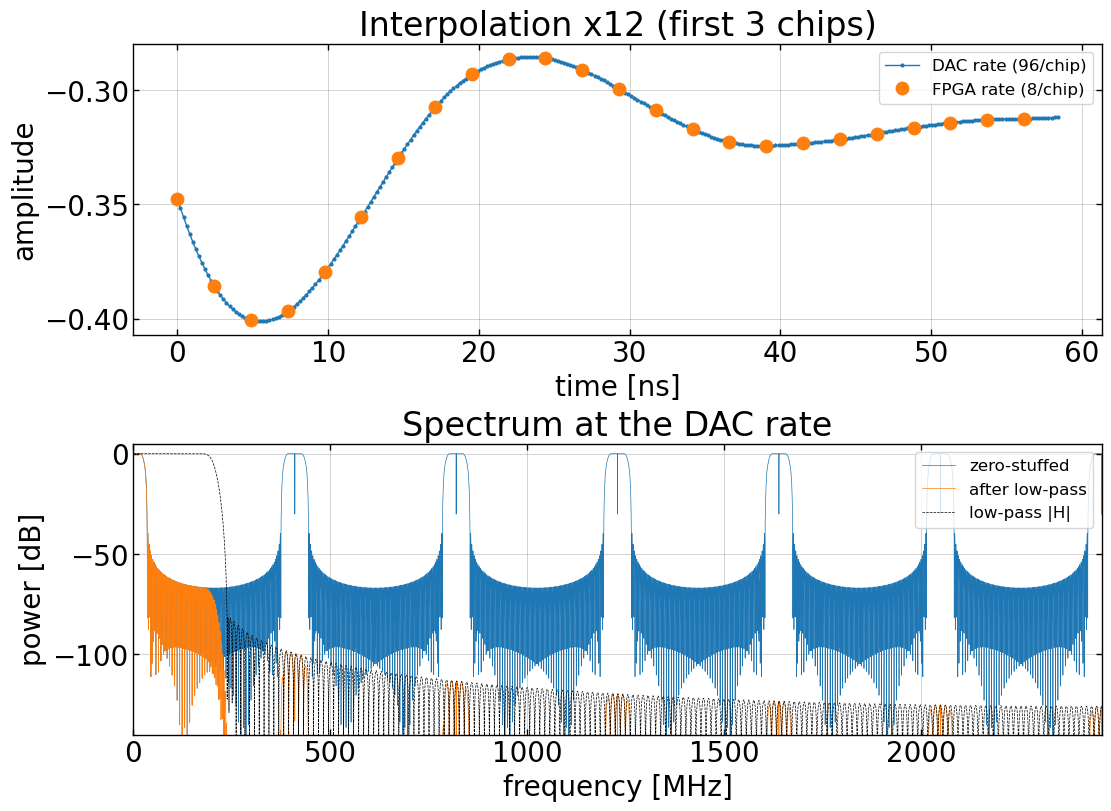

In [65]:
t_fpga = np.arange(shaped.size) / fs_FPGA     # time of every FPGA sample [s]
t_dac  = np.arange(x_dac.size) / fs_DAC       # time of every DAC sample [s]
N_ZOOM = 3                                    # chips shown in the time plot

# spectra of one code period (lines every 50 kHz), normalized to the strongest line
f_dac = np.fft.rfftfreq(x_dac.size, 1 / fs_DAC)
P_up  = np.abs(np.fft.rfft(up_dac)) ** 2
P_x   = np.abs(np.fft.rfft(x_dac)) ** 2
H_lp  = np.abs(np.fft.rfft(h_lp, x_dac.size)) / N_INTERP     # filter response, normalized to 0 dB in the passband

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(t_dac[:N_ZOOM * SPS_DAC] * 1e9, x_dac[:N_ZOOM * SPS_DAC], '.-', ms=4, lw=1, label="DAC rate (96/chip)")
ax[0].plot(t_fpga[:N_ZOOM * SPS_FPGA] * 1e9, shaped[:N_ZOOM * SPS_FPGA], 'o', ms=9, label="FPGA rate (8/chip)")
ax[0].set(xlabel="time [ns]", ylabel="amplitude", title=f"Interpolation x{N_INTERP} (first {N_ZOOM} chips)")
ax[0].legend(fontsize=12); ax[0].grid(alpha=0.3)
ax[1].plot(f_dac / 1e6, 10 * np.log10(P_up / P_up.max() + 1e-15), lw=0.5, label="zero-stuffed")
ax[1].plot(f_dac / 1e6, 10 * np.log10(P_x / P_x.max() + 1e-15), lw=0.5, label="after low-pass")
ax[1].plot(f_dac / 1e6, 20 * np.log10(H_lp + 1e-15), 'k--', lw=0.5, label="low-pass |H|")
ax[1].set(xlabel="frequency [MHz]", ylabel="power [dB]", title="Spectrum at the DAC rate",
          xlim=(0, fs_DAC / 2 / 1e6), ylim=(-140, 5))
ax[1].legend(fontsize=12, loc="upper right"); ax[1].grid(alpha=0.3)

### 4. NCO: digital up-conversion to 784.8 MHz

The NCO (numerically controlled oscillator) generates a cosine **sampled at the DAC rate**, and the mixer multiplies it with the interpolated signal, sample by sample:
$$
y[n] = x[n]\cos\left(2\pi \frac{f_{NCO}}{f_{s,DAC}}\, n\right)
$$
* The RFSoC mixer is complex ($I\cos - Q\sin$), but BPSK has $Q = 0$, so it reduces to the line above.
* Since $\cos(\omega n) = \tfrac{1}{2}\left(e^{j\omega n} + e^{-j\omega n}\right)$, multiplying by a cosine shifts the whole spectrum to $+f_{NCO}$ and to $-f_{NCO}$, each copy with half the amplitude. For a real signal the $-f_{NCO}$ copy is just the mirror image of the $+f_{NCO}$ one.
* Nyquist check: the highest frequency is now $f_{NCO} + 34.56$ MHz $= 819.4$ MHz, well below $f_{s,DAC}/2 = 2457.6$ MHz.
* 784.8 MHz is $4915.2 / 784.8 = 6.26$ DAC samples per cycle, so the NCO output looks fairly coarse in the time domain. The samples are still an exact description of the signal (Nyquist), which the spectrum shows.

**Simulation detail**: everything here works on one code period and assumes it repeats (circular convolutions, FFT delays). 784.8 MHz does not fit a whole number of cycles in one code period (15680.67 cycles), so the record would have a phase jump where it wraps around, which the real, continuous transmitter does not have. The simulation therefore uses the nearest frequency that does fit, 15681 cycles per period = 784.8164 MHz. That is 16 kHz away from the bench value, which makes no difference to anything in this notebook.

NCO frequency used: 784.8164 MHz (+16.4 kHz from the bench value)
NCO: 784.8 MHz = 6.26 DAC samples per cycle
highest signal frequency: 819.4 MHz < fs_DAC/2 = 2457.6 MHz


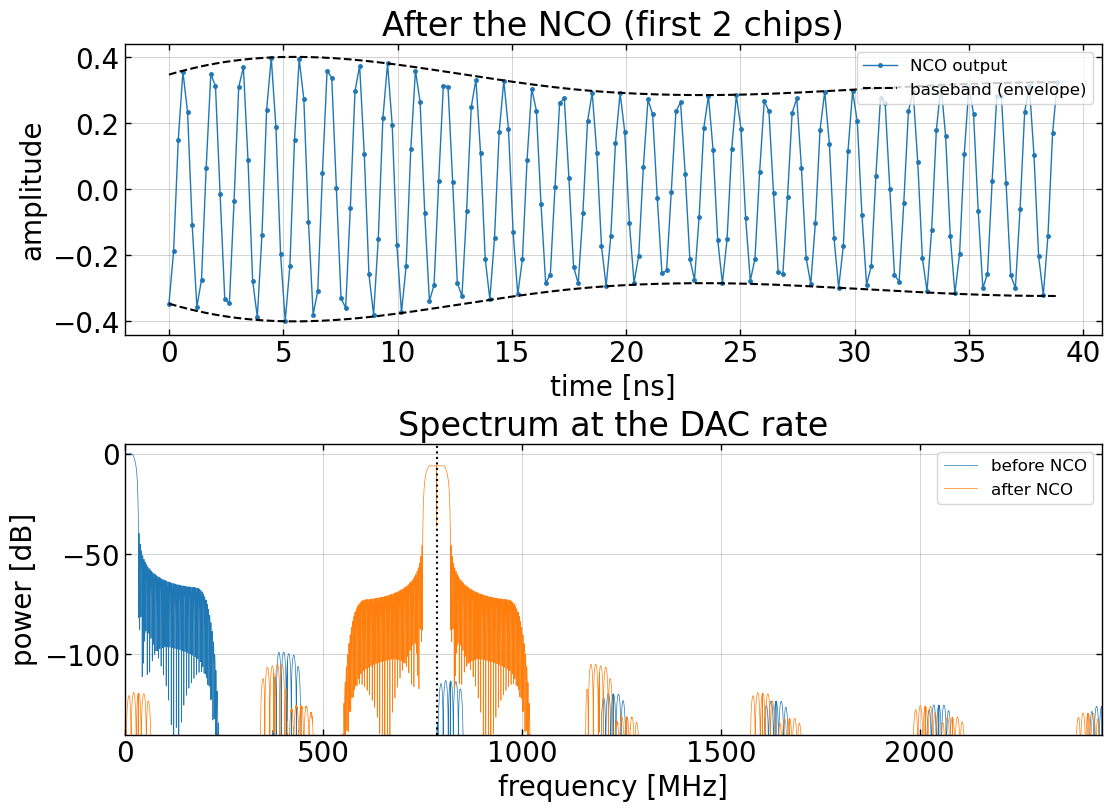

In [67]:
# 784.8 MHz (F_NCO from tx_model) puts the zone-3 image at fs_DAC + F_NCO = 5.7 GHz.
# (872.3 MHz would center the signal in the 5.725-5.850 GHz band instead.)
# Round it to a whole number of cycles per code period so the simulated record is exactly periodic:
N_CYC    = round(F_NCO / fs_DAC * x_dac.size)    # 15681 cycles per code period
F_NCO_TX = N_CYC * fs_DAC / x_dac.size           # 784.8164 MHz
print(f"NCO frequency used: {F_NCO_TX / 1e6:.4f} MHz ({(F_NCO_TX - F_NCO) / 1e3:+.1f} kHz from the bench value)")

n_dac  = np.arange(x_dac.size)                           # DAC sample index
nco_tx = np.cos(2 * np.pi * F_NCO_TX / fs_DAC * n_dac)   # the NCO: a cosine sampled at the DAC rate
y_dac  = x_dac * nco_tx                                  # the mixer: one multiplication per sample

print(f"NCO: {F_NCO_TX / 1e6:.1f} MHz = {fs_DAC / F_NCO_TX:.2f} DAC samples per cycle")
print(f"highest signal frequency: {(F_NCO_TX + (1 + BETA) * CHIP_RATE / 2) / 1e6:.1f} MHz"
      f" < fs_DAC/2 = {fs_DAC / 2 / 1e6:.1f} MHz")

P_y = np.abs(np.fft.rfft(y_dac)) ** 2
N_ZOOM = 2           # chips shown
fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(t_dac[:N_ZOOM * SPS_DAC] * 1e9, y_dac[:N_ZOOM * SPS_DAC], '.-', ms=5, lw=1, label="NCO output")
ax[0].plot(t_dac[:N_ZOOM * SPS_DAC] * 1e9, x_dac[:N_ZOOM * SPS_DAC], 'k--', lw=1.5, label="baseband (envelope)")
ax[0].plot(t_dac[:N_ZOOM * SPS_DAC] * 1e9, -x_dac[:N_ZOOM * SPS_DAC], 'k--', lw=1.5)
ax[0].set(xlabel="time [ns]", ylabel="amplitude", title=f"After the NCO (first {N_ZOOM} chips)")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
ax[1].plot(f_dac / 1e6, 10 * np.log10(P_x / P_x.max() + 1e-15), lw=0.5, label="before NCO")
ax[1].plot(f_dac / 1e6, 10 * np.log10(P_y / P_x.max() + 1e-15), lw=0.5, label="after NCO")
ax[1].axvline(F_NCO_TX / 1e6, color="k", ls=":", lw=1.5)
ax[1].set(xlabel="frequency [MHz]", ylabel="power [dB]", title="Spectrum at the DAC rate",
          xlim=(0, fs_DAC / 2 / 1e6), ylim=(-140, 5))
ax[1].legend(fontsize=12, loc="upper right"); ax[1].grid(alpha=0.3)

### 5. The DAC: from samples to a voltage, and the images

Up to here everything was numbers. The DAC turns each sample into a voltage **pulse** that lasts one sample period $T_s = 1/f_{s,DAC} = 0.203$ ns:
* **Normal (NRZ) mode**: hold the value for the whole period. Pulse response $|H(f)| = |\operatorname{sinc}(f/f_s)|$, strongest near DC.
* **Mix-mode**: (+)value for the first half of the period, (-)value for the second half. Pulse response $|H(f)| = \sin^2(u)/u$ with $u = \pi f / (2 f_s)$: zero at DC, peaks near $0.74 f_s$ (3.6 GHz). This is the mode used on the bench, because it favors Nyquist zones 2 and 3.

A sampled signal at frequency $f$ also has copies at every $k f_s \pm f$. In the digital domain these copies are only a matter of interpretation; at the DAC output they are **physically present**, each one weighted by the pulse response:
$$
P_{out}(f) = P_{digital}(f_{\text{folded}}) \times |H(f)|^2
$$
For our signal: 784.8 MHz ($k=0$), 4130.4 MHz ($f_s - f_{NCO}$, spectrally mirrored), and **5700 MHz** ($f_s + f_{NCO}$, the carrier we transmit).

To simulate a continuous voltage we draw it on a much finer "analog" time grid: `OS` = 8 points per DAC sample (39.3 GS/s, so frequencies up to 19.7 GHz are represented). Each DAC sample becomes its 8-point pulse. Drawing the half-period pulses with 4 points each is a small approximation (about 0.3 dB at 5.7 GHz).

`tx_model.py` computes exactly this step analytically (`h_mix`, `dac_output_lines`); this section is an independent, time-domain check of it.

In [11]:
DAC_MODE = "mix"     # "mix" (bench setting) or "nrz"
OS       = 8         # points per DAC sample on the "analog" time grid (even, so mix-mode can split it in half)
fs_grid  = OS * fs_DAC                 # 39.32 GS/s

# the voltage pulse produced by ONE DAC sample of value 1, drawn with OS grid points
if DAC_MODE == "mix":
    pulse = np.r_[np.ones(OS // 2), -np.ones(OS // 2)]   # +value for the first half period, -value for the second
    H_dac = h_mix                                        # analytic pulse response from tx_model
else:
    pulse = np.ones(OS)                                  # NRZ: hold the value for the whole period
    H_dac = h_nrz

# every DAC sample becomes its pulse, scaled by the sample value: [y0*pulse, y1*pulse, y2*pulse, ...]
analog = (y_dac[:, None] * pulse[None, :]).ravel()
t_grid = np.arange(analog.size) / fs_grid

# spectrum: each FFT bin divided by the record length is one spectral line's amplitude
f_grid = np.fft.rfftfreq(analog.size, 1 / fs_grid)
A_an   = np.fft.rfft(analog) / analog.size
Y_dig  = np.fft.rfft(y_dac) / y_dac.size
ref    = np.max(np.abs(Y_dig) ** 2)                      # strongest digital line = 0 dB reference
P_an_dB = 10 * np.log10(np.abs(A_an) ** 2 / ref + 1e-20)

# compare the power of each image with the analytic prediction: digital power x |H(f_image)|^2
B_HALF = (1 + BETA) * CHIP_RATE / 2 + 1e6                # half-width of the band to integrate over
P_dig  = np.sum(np.abs(Y_dig[np.abs(f_dac - F_NCO_TX) < B_HALF]) ** 2)
images = {"f_NCO": F_NCO_TX, "fs-f_NCO": fs_DAC - F_NCO_TX, "fs+f_NCO": fs_DAC + F_NCO_TX}
print("power of each image relative to the digital signal power:")
print(f"{'image':>9} {'freq [MHz]':>11} {'simulated [dB]':>15} {'|H(f)|^2 [dB]':>14}")
for name, fc in images.items():
    p_sim = np.sum(np.abs(A_an[np.abs(f_grid - fc) < B_HALF]) ** 2)
    p_th  = P_dig * H_dac(fc)[0] ** 2
    print(f"{name:>9} {fc / 1e6:11.1f} {10 * np.log10(p_sim / P_dig):15.2f} {10 * np.log10(p_th / P_dig):14.2f}")

power of each image relative to the digital signal power:
    image  freq [MHz]  simulated [dB]  |H(f)|^2 [dB]
    f_NCO       784.8          -12.19         -12.20
 fs-f_NCO      4130.4           -2.81          -2.96
 fs+f_NCO      5700.0           -5.46          -5.76


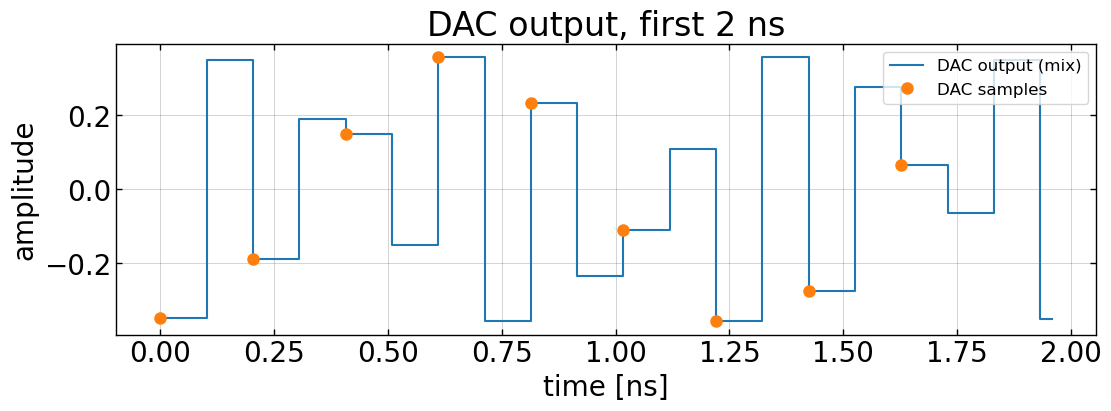

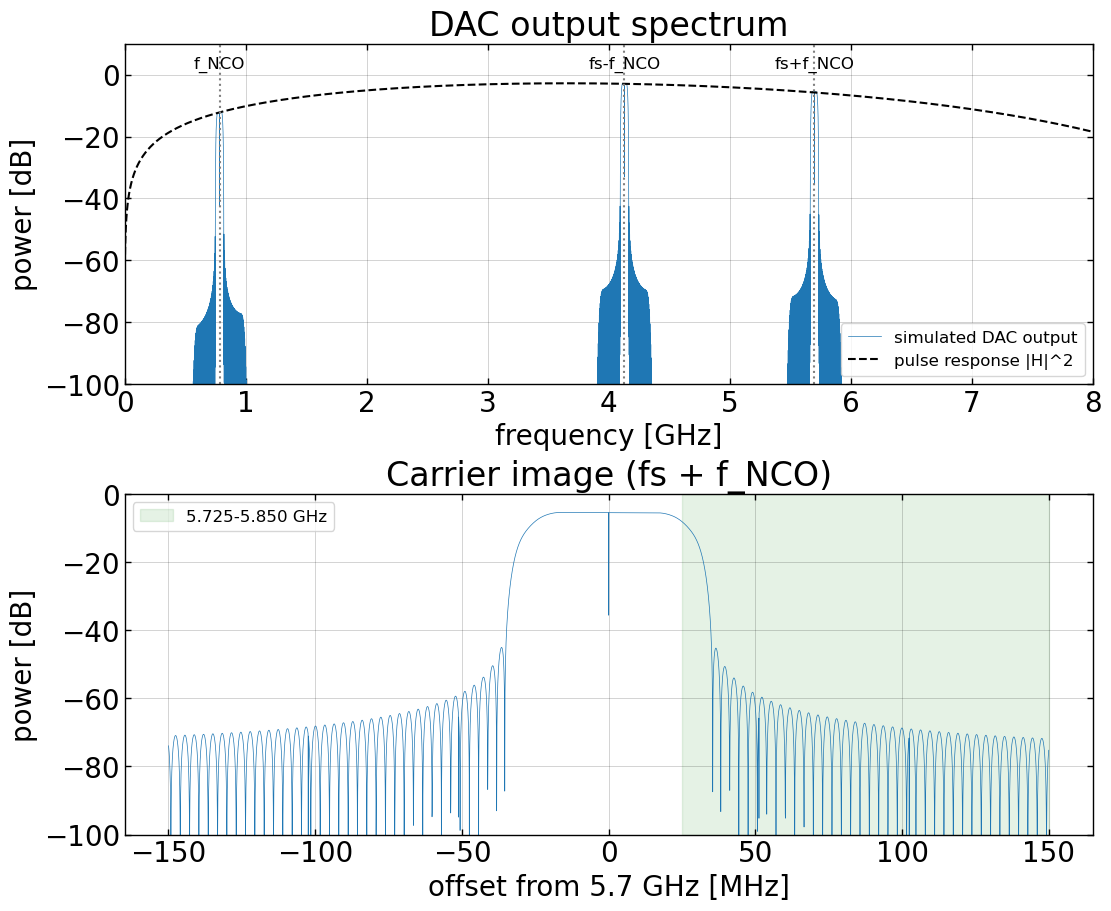

In [12]:
# time domain: the DAC samples and the voltage the DAC actually produces
N_NS = 2.0                                               # nanoseconds shown
m_dac, m_grid = int(N_NS * 1e-9 * fs_DAC), int(N_NS * 1e-9 * fs_grid)
fig, ax = plt.subplots(figsize=(11, 4), layout='constrained')
ax.step(t_grid[:m_grid] * 1e9, analog[:m_grid], where="post", lw=1.5, label=f"DAC output ({DAC_MODE})")
ax.plot(t_dac[:m_dac] * 1e9, y_dac[:m_dac], 'o', ms=8, label="DAC samples")
ax.set(xlabel="time [ns]", ylabel="amplitude", title=f"DAC output, first {N_NS:g} ns")
ax.legend(fontsize=12, loc="upper right"); ax.grid(alpha=0.3)

# frequency domain: full span and zoom on the carrier image
fig, ax = plt.subplots(2, 1, figsize=(11, 9), layout='constrained')
ax[0].plot(f_grid / 1e9, P_an_dB, lw=0.5, label="simulated DAC output")
ax[0].plot(f_grid / 1e9, 20 * np.log10(H_dac(f_grid) + 1e-12), 'k--', lw=1.5, label="pulse response |H|^2")
for name, fc in images.items():
    ax[0].axvline(fc / 1e9, color="gray", ls=":", lw=1.5)
    ax[0].annotate(name, (fc / 1e9, 2), ha="center", fontsize=12)
ax[0].set(xlabel="frequency [GHz]", ylabel="power [dB]", title="DAC output spectrum",
          xlim=(0, 8), ylim=(-100, 10))
ax[0].legend(fontsize=12, loc="lower right"); ax[0].grid(alpha=0.3)
sel = np.abs(f_grid - F_CARRIER) < 150e6
ax[1].plot((f_grid[sel] - F_CARRIER) / 1e6, P_an_dB[sel], lw=0.5)
ax[1].axvspan((5.725e9 - F_CARRIER) / 1e6, (5.850e9 - F_CARRIER) / 1e6, color="green", alpha=0.1,
              label="5.725-5.850 GHz")
ax[1].set(xlabel=f"offset from {F_CARRIER / 1e9:.1f} GHz [MHz]", ylabel="power [dB]",
          title="Carrier image (fs + f_NCO)", ylim=(-100, 0))
ax[1].legend(fontsize=12, loc="upper left"); ax[1].grid(alpha=0.3)

# Channel

### 6. TX band-pass filter, propagation delay and noise

#### 6a. TX band-pass filter

The DAC output contains every image. Only the 5.7 GHz one should be transmitted, so an analog band-pass filter (BPF) follows the DAC. It is modeled here by the magnitude of a Butterworth band-pass:
$$
|H_{BPF}(f)| = \frac{1}{\sqrt{1 + \left(\dfrac{f - f_c}{B/2}\right)^{2N}}}
$$
with center $f_c = 5.7$ GHz, passband $B$ and order $N$. The model is zero-phase: a real filter also delays the signal by a fixed amount (its group delay), which, like every other fixed delay in the chain, is removed by calibration.

BPF attenuation at     f_NCO ( 784.8 MHz):  135.3 dB
BPF attenuation at  fs-f_NCO (4130.4 MHz):   95.7 dB
BPF attenuation at  fs+f_NCO (5700.0 MHz):   -0.0 dB


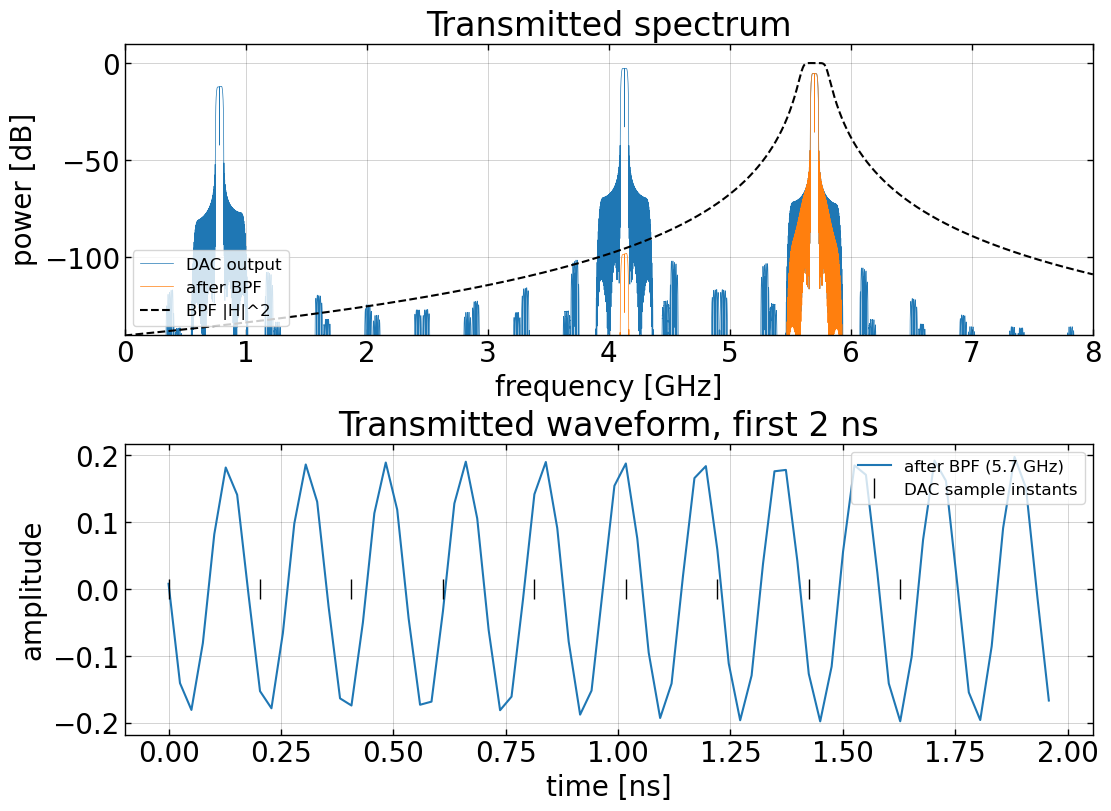

In [13]:
BPF_FC    = F_CARRIER      # 5.7 GHz: the image we keep
BPF_BW    = 200e6          # passband width [Hz]
BPF_ORDER = 4              # steepness of the roll-off

H_bpf = 1 / np.sqrt(1 + ((f_grid - BPF_FC) / (BPF_BW / 2)) ** (2 * BPF_ORDER))   # on the analog-grid frequencies
tx_rf = np.fft.irfft(np.fft.rfft(analog) * H_bpf, analog.size)                    # filter = multiply the spectrum

for name, fc in images.items():
    print(f"BPF attenuation at {name:>9} ({fc / 1e6:6.1f} MHz): {-20 * np.log10(H_bpf[np.argmin(np.abs(f_grid - fc))]):6.1f} dB")

P_tx_dB = 10 * np.log10(np.abs(np.fft.rfft(tx_rf) / tx_rf.size) ** 2 / ref + 1e-20)
fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(f_grid / 1e9, P_an_dB, lw=0.5, label="DAC output")
ax[0].plot(f_grid / 1e9, P_tx_dB, lw=0.5, label="after BPF")
ax[0].plot(f_grid / 1e9, 20 * np.log10(H_bpf + 1e-12), 'k--', lw=1.5, label="BPF |H|^2")
ax[0].set(xlabel="frequency [GHz]", ylabel="power [dB]", title="Transmitted spectrum", xlim=(0, 8), ylim=(-140, 10))
ax[0].legend(fontsize=12, loc="lower left"); ax[0].grid(alpha=0.3)
N_NS = 2.0
m_grid = int(N_NS * 1e-9 * fs_grid)
ax[1].plot(t_grid[:m_grid] * 1e9, tx_rf[:m_grid], lw=1.5, label="after BPF (5.7 GHz)")
ax[1].plot(t_dac[:int(N_NS * 1e-9 * fs_DAC)] * 1e9, np.zeros(int(N_NS * 1e-9 * fs_DAC)), '|', ms=15, color="k",
           label="DAC sample instants")
ax[1].set(xlabel="time [ns]", ylabel="amplitude", title=f"Transmitted waveform, first {N_NS:g} ns")
ax[1].legend(fontsize=12, loc="upper right"); ax[1].grid(alpha=0.3)

#### 6b. Propagation: delay and noise

* **Delay** $\tau$: the quantity the whole system is built to measure. It is applied in the frequency domain, $X(f) \rightarrow X(f)\,e^{-j2\pi f\tau}$, which delays by **any** amount, including fractions of a sample. Because the record is one period of a repeating signal, the delay wraps around circularly, just like the continuous transmission would.
* **Attenuation** is left out: only the ratio of signal to noise matters, and everything is normalized.
* **Noise**: white Gaussian noise across the whole analog grid. Its level is set by the SNR **inside the signal bandwidth** $B_{sig} = (1+\beta) R_c = 69.1$ MHz. White noise of variance $\sigma^2$ on a grid sampled at $f_{s,grid}$ has a one-sided density of $\sigma^2 / (f_{s,grid}/2)$, so
$$
\sigma^2 = \frac{P_{signal}}{\text{SNR}}\cdot\frac{f_{s,grid}}{2 B_{sig}}
$$
The noise outside the signal band is much larger in total than the signal, so in the time domain the signal disappears. It is still there in the spectrum, and the correlation will find it.

delay: 123.4567 ns = 6.321 chips = 50.57 FPGA samples = 37.011 m
total noise power / signal power: 14.5 dB (whole 19.7 GHz grid)


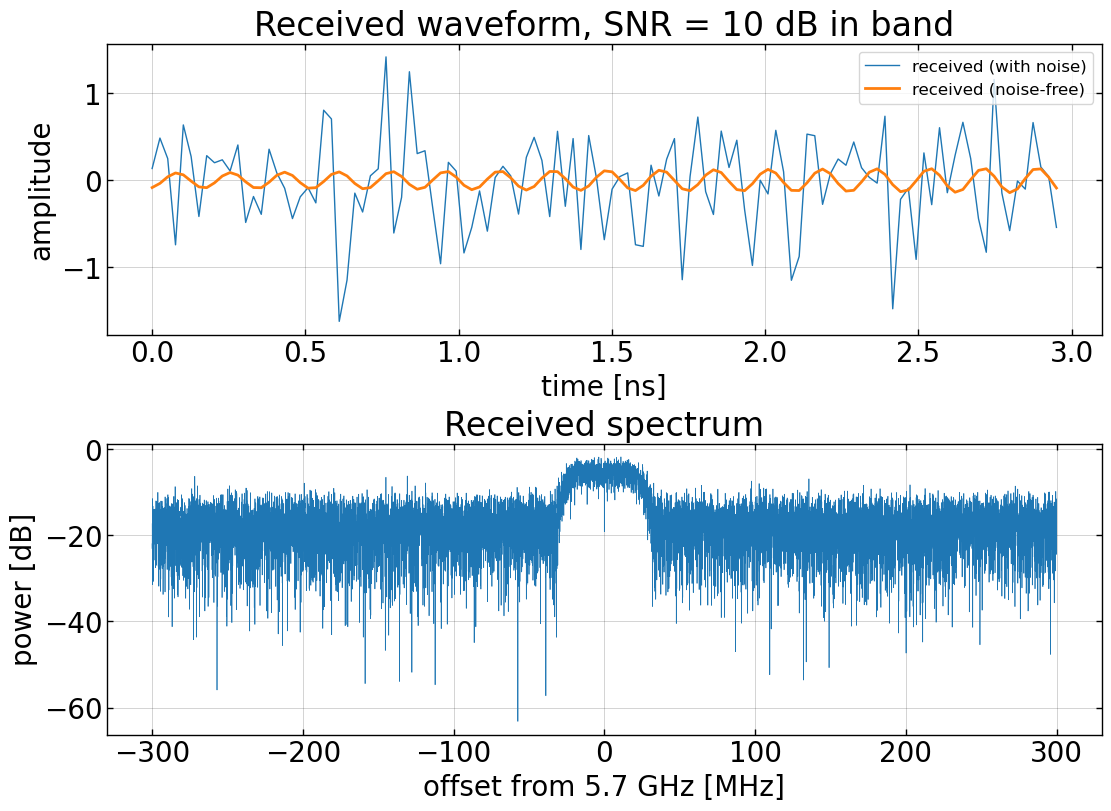

In [14]:
TAU    = 123.4567e-9      # true propagation delay [s] -> 37.0 m of path, 6.32 chips. The receiver has to find this.
SNR_DB = 10               # SNR inside the 69 MHz signal bandwidth at the receiver input [dB] (try -10 or -20)
rng    = np.random.default_rng(1)

C_LIGHT = 299_792_458.0
B_SIG   = (1 + BETA) * CHIP_RATE                      # 69.1 MHz
print(f"delay: {TAU * 1e9:.4f} ns = {TAU * CHIP_RATE:.3f} chips = {TAU * fs_FPGA:.2f} FPGA samples = {C_LIGHT * TAU:.3f} m")

# delay: multiply the spectrum by exp(-j 2 pi f tau)
rx_clean = np.fft.irfft(np.fft.rfft(tx_rf) * np.exp(-2j * np.pi * f_grid * TAU), tx_rf.size)

# noise: scaled so that the power inside the signal bandwidth is P_signal / SNR
P_sig  = np.mean(rx_clean ** 2)
sigma2 = P_sig / 10 ** (SNR_DB / 10) * fs_grid / (2 * B_SIG)
rx_rf  = rx_clean + rng.normal(0, np.sqrt(sigma2), rx_clean.size)
print(f"total noise power / signal power: {10 * np.log10(sigma2 / P_sig):.1f} dB (whole 19.7 GHz grid)")

P_rx_dB = 10 * np.log10(np.abs(np.fft.rfft(rx_rf) / rx_rf.size) ** 2 / ref + 1e-20)
fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
m_grid = int(3e-9 * fs_grid)
ax[0].plot(t_grid[:m_grid] * 1e9, rx_rf[:m_grid], lw=1, label="received (with noise)")
ax[0].plot(t_grid[:m_grid] * 1e9, rx_clean[:m_grid], lw=2, label="received (noise-free)")
ax[0].set(xlabel="time [ns]", ylabel="amplitude", title=f"Received waveform, SNR = {SNR_DB} dB in band")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
sel = np.abs(f_grid - F_CARRIER) < 300e6
ax[1].plot((f_grid[sel] - F_CARRIER) / 1e6, P_rx_dB[sel], lw=0.5)
ax[1].set(xlabel=f"offset from {F_CARRIER / 1e9:.1f} GHz [MHz]", ylabel="power [dB]", title="Received spectrum")
ax[1].grid(alpha=0.3)

# ADC Side (receiver)

### 7. RX band-pass filter and ADC (direct RF sampling)

The ADC samples the 5.7 GHz signal **directly**, with no analog mixer. Sampling folds every frequency into the first Nyquist zone, so the image relation from section 5 now works in reverse. Assuming the ADC also runs at 4.9152 GS/s (check the base overlay):
$$
5700 - 4915.2 = 784.8 \text{ MHz}
$$
The signal shows up in the ADC samples at 784.8 MHz. This is called undersampling, or band-pass sampling.

The catch: **every** frequency $k f_s \pm 784.8$ MHz folds onto the same spot (784.8, 4130.4, 5700, 9830.4, ... MHz). Noise and interference from all those zones would land on top of the signal, so a band-pass filter has to remove them **before** the ADC. After sampling they cannot be separated anymore. The last line printed below measures this: the in-band noise at the ADC output with and without the RX BPF.

The ADC itself is modeled as taking one point of the analog grid every $1/f_{s,ADC}$ (an ideal sampler: no analog bandwidth limit, no quantization).

in-band noise without RX BPF is 9.4 dB higher (all 19.7 GHz of noise in this model fold into 2.46 GHz)


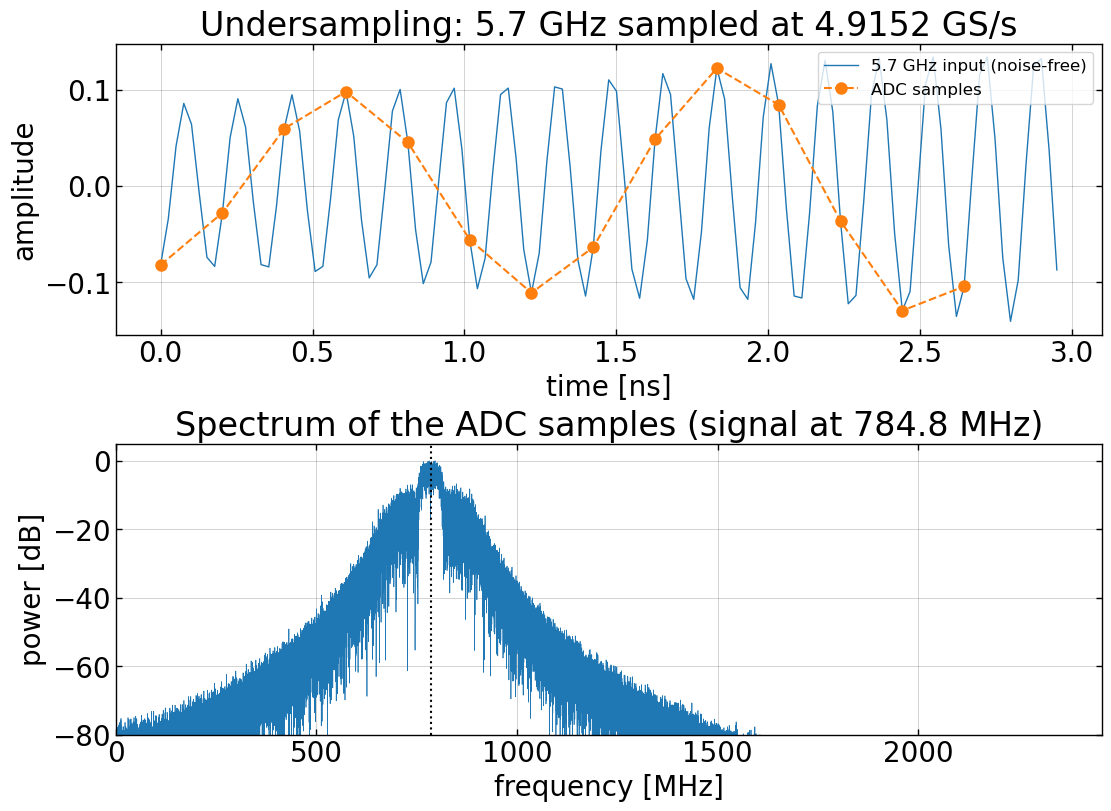

In [15]:
FS_ADC = fs_DAC                          # ADC sample rate (assumed equal to the DAC rate)
OS_ADC = int(round(fs_grid / FS_ADC))    # analog-grid points per ADC sample (8)

rx_bpf   = np.fft.irfft(np.fft.rfft(rx_rf) * H_bpf, rx_rf.size)           # RX band-pass, same filter as TX
rx_bpf_c = np.fft.irfft(np.fft.rfft(rx_clean) * H_bpf, rx_clean.size)     # noise-free copy, used for plots only
adc      = rx_bpf[::OS_ADC]              # the ADC: one value every 1/FS_ADC
adc_c    = rx_bpf_c[::OS_ADC]
t_adc    = np.arange(adc.size) / FS_ADC
f_adc    = np.fft.rfftfreq(adc.size, 1 / FS_ADC)

# noise folding: in-band noise at the ADC output, without and with the RX BPF
w = rng.normal(0, np.sqrt(sigma2), rx_rf.size)                            # noise alone
band = np.abs(f_adc - F_NCO_TX) < B_SIG / 2
p_no_bpf = np.sum(np.abs(np.fft.rfft(w[::OS_ADC])[band]) ** 2)
p_bpf    = np.sum(np.abs(np.fft.rfft(np.fft.irfft(np.fft.rfft(w) * H_bpf, w.size)[::OS_ADC])[band]) ** 2)
print(f"in-band noise without RX BPF is {10 * np.log10(p_no_bpf / p_bpf):.1f} dB higher "
      f"(all {fs_grid / 2 / 1e9:.1f} GHz of noise in this model fold into {FS_ADC / 2 / 1e9:.2f} GHz)")

P_adc = np.abs(np.fft.rfft(adc) / adc.size) ** 2
fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
N_NS = 3.0
m_grid, m_adc = int(N_NS * 1e-9 * fs_grid), int(N_NS * 1e-9 * FS_ADC)
ax[0].plot(t_grid[:m_grid] * 1e9, rx_bpf_c[:m_grid], lw=1, label="5.7 GHz input (noise-free)")
ax[0].plot(t_adc[:m_adc] * 1e9, adc_c[:m_adc], 'o--', ms=8, lw=1.5, label="ADC samples")
ax[0].set(xlabel="time [ns]", ylabel="amplitude", title="Undersampling: 5.7 GHz sampled at 4.9152 GS/s")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
ax[1].plot(f_adc / 1e6, 10 * np.log10(P_adc / P_adc.max() + 1e-15), lw=0.5)
ax[1].axvline(F_NCO_TX / 1e6, color="k", ls=":", lw=1.5)
ax[1].set(xlabel="frequency [MHz]", ylabel="power [dB]", title="Spectrum of the ADC samples (signal at 784.8 MHz)",
          xlim=(0, FS_ADC / 2 / 1e6), ylim=(-80, 5))
ax[1].grid(alpha=0.3)

### 8. RX NCO: down-conversion to complex baseband (I/Q)

The RX NCO multiplies the ADC samples by a **complex** exponential at $-f_{NCO}$:
$$
z[n] = x[n]\, e^{-j\left(2\pi \frac{f_{NCO}}{f_{s,ADC}} n + \phi\right)} = \underbrace{x[n]\cos(\cdot)}_{I} - j\,\underbrace{x[n]\sin(\cdot)}_{Q}
$$
* This shifts the whole spectrum **down** by 784.8 MHz: the signal at $+784.8$ lands at 0 Hz, and its mirror at $-784.8$ moves to $-1569.6$ MHz (removed by the decimation filter in section 9).
* **Why complex (I and Q)**: the RX oscillator is not phase-locked to the TX one, so there is an unknown phase $\phi$ between them (plus the carrier phase from the delay, $2\pi f_c \tau$). With a real cosine alone the result would be $b\cos\phi$, which vanishes at $\phi = 90°$. With I and Q you get $b\cos\phi$ and $b\sin\phi$: the signal is always there, split between the two.
* `F_ERR` models a frequency error between TX and RX oscillators (separate clocks). It makes the phase rotate slowly over time; try 20e3 and look at the constellation in section 12.

On the RFSoC, this NCO and the decimation are inside the RF Data Converter, mirroring the DAC side.

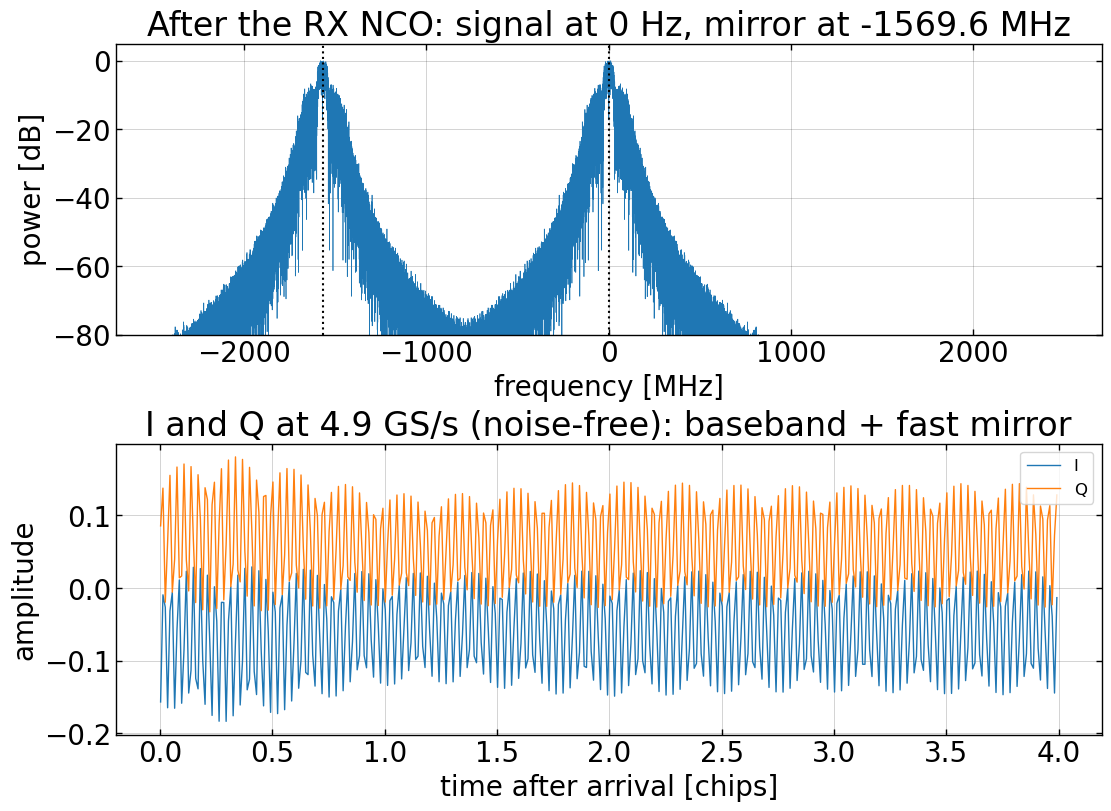

In [16]:
PHI_RX = 1.0      # RX NCO phase offset [rad]: unknown to the receiver
F_ERR  = 0.0      # RX NCO frequency error [Hz] (try 20e3)

n_adc   = np.arange(adc.size)
lo_rx   = np.exp(-1j * (2 * np.pi * (F_NCO_TX + F_ERR) / FS_ADC * n_adc + PHI_RX))   # complex NCO: cos - j sin
z_adc   = adc * lo_rx            # I = z_adc.real, Q = z_adc.imag
z_adc_c = adc_c * lo_rx          # noise-free copy for plots

# complex signal -> two-sided spectrum (negative and positive frequencies are now different)
f_adc2 = np.fft.fftshift(np.fft.fftfreq(z_adc.size, 1 / FS_ADC))
P_z    = np.fft.fftshift(np.abs(np.fft.fft(z_adc)) ** 2)
fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(f_adc2 / 1e6, 10 * np.log10(P_z / P_z.max() + 1e-15), lw=0.5)
for fv in (0, -2 * F_NCO_TX):
    ax[0].axvline(fv / 1e6, color="k", ls=":", lw=1.5)
ax[0].set(xlabel="frequency [MHz]", ylabel="power [dB]", title="After the RX NCO: signal at 0 Hz, mirror at -1569.6 MHz",
          ylim=(-80, 5))
ax[0].grid(alpha=0.3)
N_ZOOM = 4
m = N_ZOOM * SPS_DAC
t0 = TAU                                                   # start the plot where the delayed signal starts
i0 = int(round(t0 * FS_ADC))
ax[1].plot((t_adc[i0:i0 + m] - t0) * CHIP_RATE, z_adc_c.real[i0:i0 + m], lw=1, label="I")
ax[1].plot((t_adc[i0:i0 + m] - t0) * CHIP_RATE, z_adc_c.imag[i0:i0 + m], lw=1, label="Q")
ax[1].set(xlabel="time after arrival [chips]", ylabel="amplitude", title="I and Q at 4.9 GS/s (noise-free): baseband + fast mirror")
ax[1].legend(fontsize=12, loc="upper right"); ax[1].grid(alpha=0.3)

### 9. Decimation ÷12: back to the FPGA rate

The reverse of section 3:
* **Low-pass filter** first, to remove everything outside the baseband: the $-1569.6$ MHz mirror and the noise outside $\pm$ 204.8 MHz. This has to happen **before** dropping samples, otherwise all of it would fold into the band (the same aliasing as in section 7, now digital).
* **Keep every 12th sample**: 4.9152 GS/s $\rightarrow$ 409.6 MS/s, 8 samples per chip again.

The same windowed-sinc filter as in section 3 does the job, with unit gain this time (decimation does not dilute the signal the way zero-stuffing did).

98208 samples at 4.9152 GS/s -> 8184 samples at 409.6 MS/s


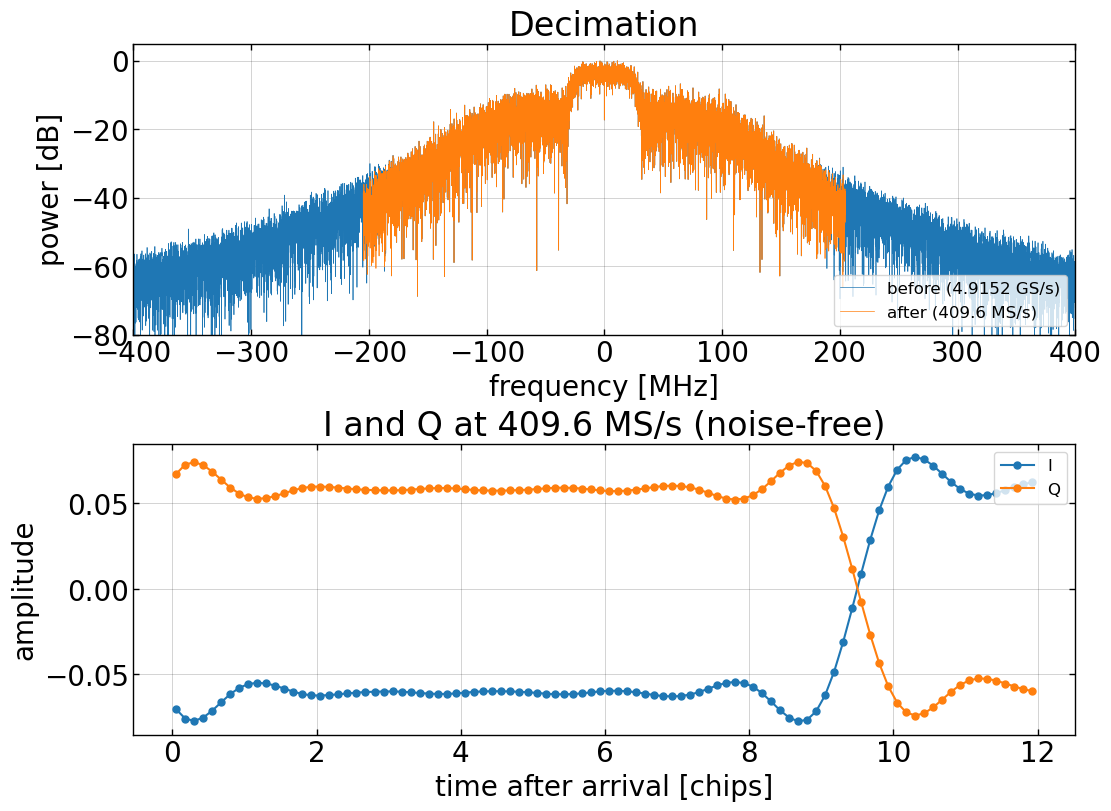

In [17]:
h_dec = h_lp / N_INTERP           # same low-pass as the interpolator, unit gain

def lowpass_decimate(z):
    # low-pass (circular convolution, delay removed) then keep every N_INTERP-th sample
    z_lp = np.fft.ifft(np.fft.fft(z) * np.fft.fft(h_dec, z.size))
    return np.roll(z_lp, -(h_dec.size // 2))[::N_INTERP]

z_bb   = lowpass_decimate(z_adc)          # 409.6 MS/s, complex
z_bb_c = lowpass_decimate(z_adc_c)
print(f"{z_adc.size} samples at {FS_ADC / 1e9:.4f} GS/s -> {z_bb.size} samples at {fs_FPGA / 1e6:.1f} MS/s")

f_bb = np.fft.fftshift(np.fft.fftfreq(z_bb.size, 1 / fs_FPGA))
P_bb = np.fft.fftshift(np.abs(np.fft.fft(z_bb)) ** 2)
fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(f_adc2 / 1e6, 10 * np.log10(P_z / P_z.max() + 1e-15), lw=0.5, label="before (4.9152 GS/s)")
ax[0].plot(f_bb / 1e6, 10 * np.log10(P_bb / P_bb.max() + 1e-15), lw=0.5, label="after (409.6 MS/s)")
ax[0].set(xlabel="frequency [MHz]", ylabel="power [dB]", title="Decimation", xlim=(-400, 400), ylim=(-80, 5))
ax[0].legend(fontsize=12, loc="lower right"); ax[0].grid(alpha=0.3)
# the mirror is gone and the shaped chips are back, split between I and Q (first N_SHOW chips after arrival)
i0 = int(round(TAU * fs_FPGA))
t_bb = (np.arange(i0, i0 + N_SHOW * SPS_FPGA) / fs_FPGA - TAU) * CHIP_RATE
ax[1].plot(t_bb, z_bb_c.real[i0:i0 + N_SHOW * SPS_FPGA], 'o-', ms=5, lw=1.5, label="I")
ax[1].plot(t_bb, z_bb_c.imag[i0:i0 + N_SHOW * SPS_FPGA], 'o-', ms=5, lw=1.5, label="Q")
ax[1].set(xlabel="time after arrival [chips]", ylabel="amplitude", title="I and Q at 409.6 MS/s (noise-free)")
ax[1].legend(fontsize=12, loc="upper right"); ax[1].grid(alpha=0.3)

# Receiver FPGA Side

### 10. Matched RRC filter

The second RRC (section 2d): RX RRC $\times$ TX RRC = raised cosine, which gives zero ISI at the chip instants and the best possible SNR. It is applied to I and Q alike (they are just the real and imaginary parts of one complex signal).

The plot shows the problem the next two sections solve. Sampling every 8th sample does **not** give clean BPSK points, because:
* the samples are not at the chip instants: the delay is 6.32 chips, so the chips sit 0.32 chip (2.6 samples) away from the sample grid,
* the unknown phase rotates the BPSK points off the real axis, onto a line at some angle in the I/Q plane.

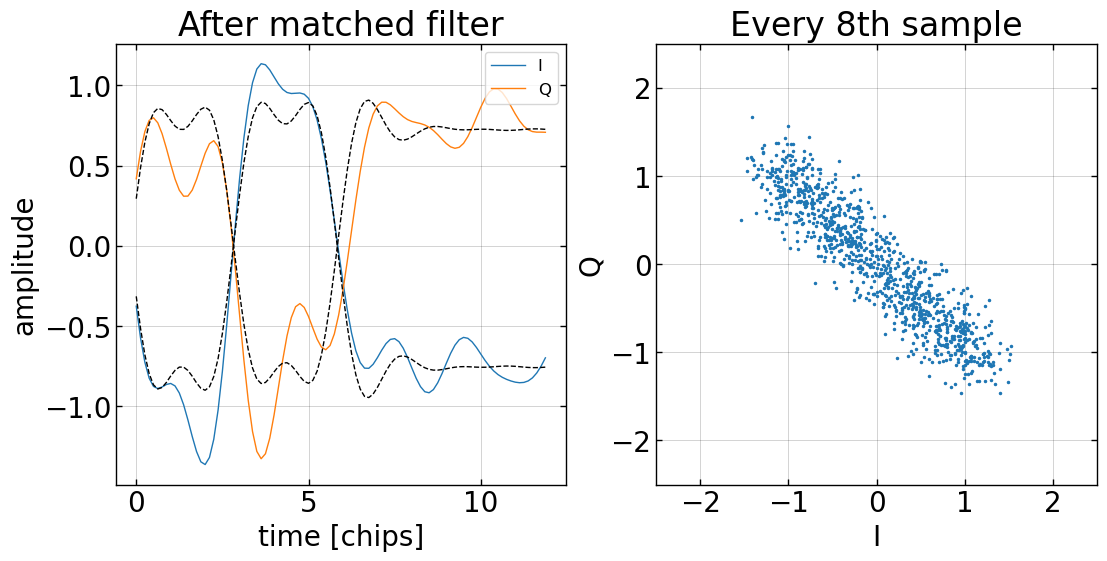

In [18]:
def matched_filter(z):
    # RX RRC: same taps h as the TX (section 2b), circular convolution, delay removed
    return np.roll(np.fft.ifft(np.fft.fft(z) * np.fft.fft(h, z.size)), -delay)

z_mf   = matched_filter(z_bb)
z_mf_c = matched_filter(z_bb_c)
scale  = np.sqrt(np.mean(np.abs(z_mf_c) ** 2))          # normalize to unit RMS for plotting
z_mf, z_mf_c = z_mf / scale, z_mf_c / scale

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5), layout='constrained')
m = N_SHOW * SPS_FPGA
t_ch = np.arange(m) / SPS_FPGA
ax[0].plot(t_ch, z_mf.real[:m], lw=1, label="I")
ax[0].plot(t_ch, z_mf.imag[:m], lw=1, label="Q")
ax[0].plot(t_ch, z_mf_c.real[:m], 'k--', lw=1)
ax[0].plot(t_ch, z_mf_c.imag[:m], 'k--', lw=1)
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="After matched filter")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
ax[1].plot(z_mf.real[::SPS_FPGA], z_mf.imag[::SPS_FPGA], '.', ms=3)
ax[1].set(xlabel="I", ylabel="Q", title="Every 8th sample", aspect="equal", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
ax[1].grid(alpha=0.3)

### 11. Correlation with the PRN code

Slide a local copy of the chip pattern across the received signal and, at every shift $m$, multiply and sum:
$$
R[m] = \sum_n z_{MF}[n+m]\; u[n]
$$
where $u$ is the zero-stuffed chip pattern from 2a (`up`). Because the code repeats, this is a **circular** correlation, computed with FFTs: $R = \mathrm{IFFT}\{\mathrm{FFT}(z_{MF}) \cdot \mathrm{FFT}(u)^*\}$.

* **Non-coherent**: $R$ is complex, with the unknown phase on it. Its magnitude $|R|$ does not depend on the phase.
* **Processing gain**: at the right shift the 1023 chips add up coherently, while the noise adds up randomly. The SNR improves by $10\log_{10}(1023) = 30.1$ dB, which is why the peak is clear even when the signal is invisible in the time domain.
* **Peak shape**: the m-sequence's autocorrelation is nearly an impulse, so $|R|$ around the peak has the shape of the end-to-end pulse, the **raised cosine**. The zoom compares the samples with the theoretical RC shifted by the true delay.

peak at 6.375 chips (true delay 6.321 chips)
peak / RMS off-peak: 41.2 dB  (in-band SNR 10 dB + processing gain 30.1 dB)


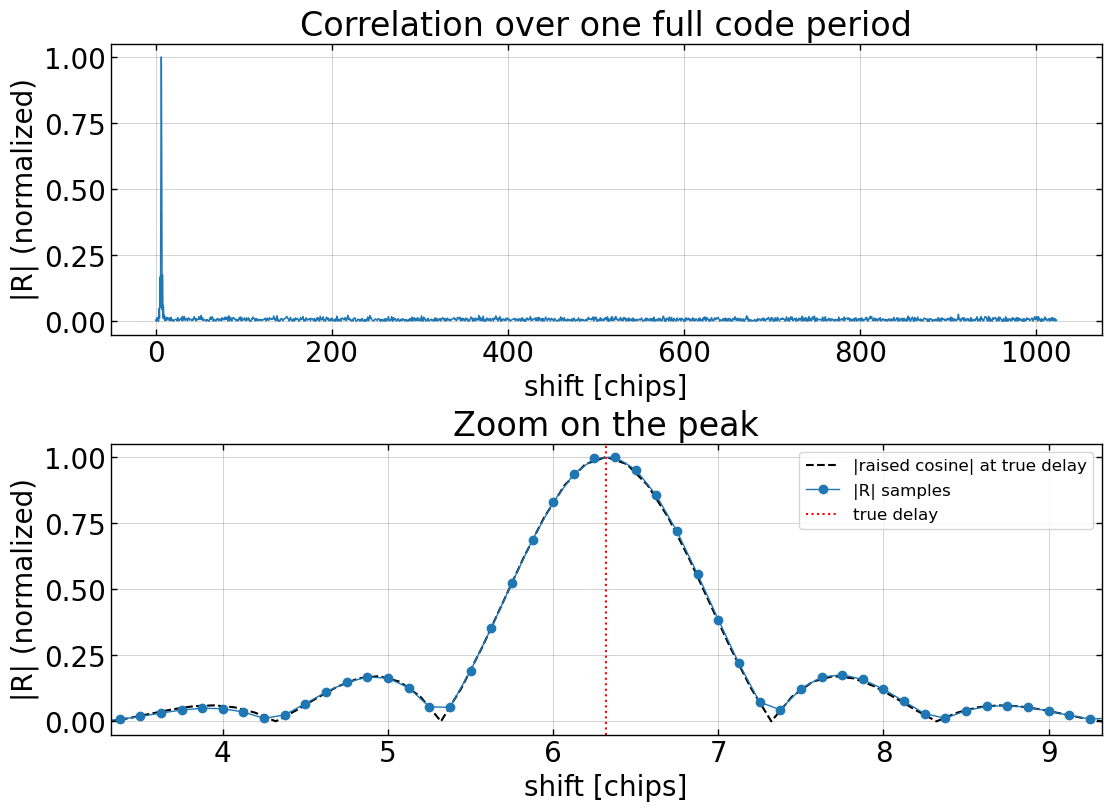

In [19]:
R     = np.fft.ifft(np.fft.fft(z_mf) * np.conj(np.fft.fft(up)))   # circular cross-correlation with the chip pattern
R_mag = np.abs(R)
lags  = np.arange(R.size) / SPS_FPGA                             # shift in chips

m_pk = np.argmax(R_mag)
off  = np.abs(lags - lags[m_pk]) > 3                             # everything more than 3 chips from the peak
print(f"peak at {lags[m_pk]:.3f} chips (true delay {TAU * CHIP_RATE:.3f} chips)")
print(f"peak / RMS off-peak: {20 * np.log10(R_mag[m_pk] / np.sqrt(np.mean(R_mag[off] ** 2))):.1f} dB"
      f"  (in-band SNR {SNR_DB} dB + processing gain {10 * np.log10(chips.size):.1f} dB)")

# theoretical shape: the raised cosine = RRC * RRC, centered on the true delay
rc   = np.convolve(h, h)
t_rc = (np.arange(rc.size) - rc.size // 2) / SPS_FPGA

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(lags, R_mag / R_mag[m_pk], lw=1)
ax[0].set(xlabel="shift [chips]", ylabel="|R| (normalized)", title="Correlation over one full code period")
ax[0].grid(alpha=0.3)
ax[1].plot(t_rc + TAU * CHIP_RATE, np.abs(rc) / rc.max(), 'k--', lw=1.5, label="|raised cosine| at true delay")
ax[1].plot(lags, R_mag / R_mag[m_pk], 'o-', ms=6, lw=1, label="|R| samples")
ax[1].axvline(TAU * CHIP_RATE, color="r", ls=":", lw=1.5, label="true delay")
ax[1].set(xlabel="shift [chips]", ylabel="|R| (normalized)", title="Zoom on the peak",
          xlim=(TAU * CHIP_RATE - 3, TAU * CHIP_RATE + 3))
ax[1].legend(fontsize=12, loc="upper right"); ax[1].grid(alpha=0.3)

### 12. Timing and phase estimate

**Coarse timing**: the index of the largest $|R|$, a resolution of one sample (1/8 chip = 2.44 ns = 73 cm).

**Fine timing**: fit a parabola through the peak sample and its two neighbours $y_{-1}, y_0, y_{+1}$. Its vertex is at
$$
\delta = \frac{1}{2}\,\frac{y_{-1} - y_{+1}}{y_{-1} - 2y_0 + y_{+1}} \quad \text{samples from the peak sample}
$$
The raised cosine is not exactly a parabola, so this has a small systematic error (bias) that depends on where the true delay falls between samples. Fitting the actual RC shape removes it.

**Phase**: the angle of $R$ at the peak is the total phase between TX and RX (NCO offset plus carrier phase from the delay).

With both, the receiver can undo the delay and the phase and read the chips: the constellation collapses onto two points at $\pm 1$ on the real axis (BPSK).

**Fixed delays**: in this simulation every digital filter delay was already removed (the `np.roll`s), and the band-pass filters are zero-phase. One fixed delay is left, and it is physical: the DAC pulse for each sample is centered **half a DAC sample after** the sample instant (the mix-mode pulse spans $0 \ldots T_s$), so everything arrives $T_s/2 \approx 0.1$ ns late. On the analog grid used here, the pulse center is 3.5 grid points = 89 ps after the sample. This is known, so it is subtracted. In hardware the same idea applies to all fixed delays (RRC filters, interpolation and decimation, converter pipelines, analog filters, cables): they add a constant offset that is measured once with a known path and subtracted.

true delay     :   123.4567 ns
coarse estimate:   124.4227 ns   error    966.0 ps =   29.0 cm
fine estimate  :   123.4646 ns   error      7.9 ps =    0.2 cm
phase          : -43.5 deg      (fixed DAC delay subtracted: 89.0 ps)
chip errors after timing + phase correction: 0 / 1023


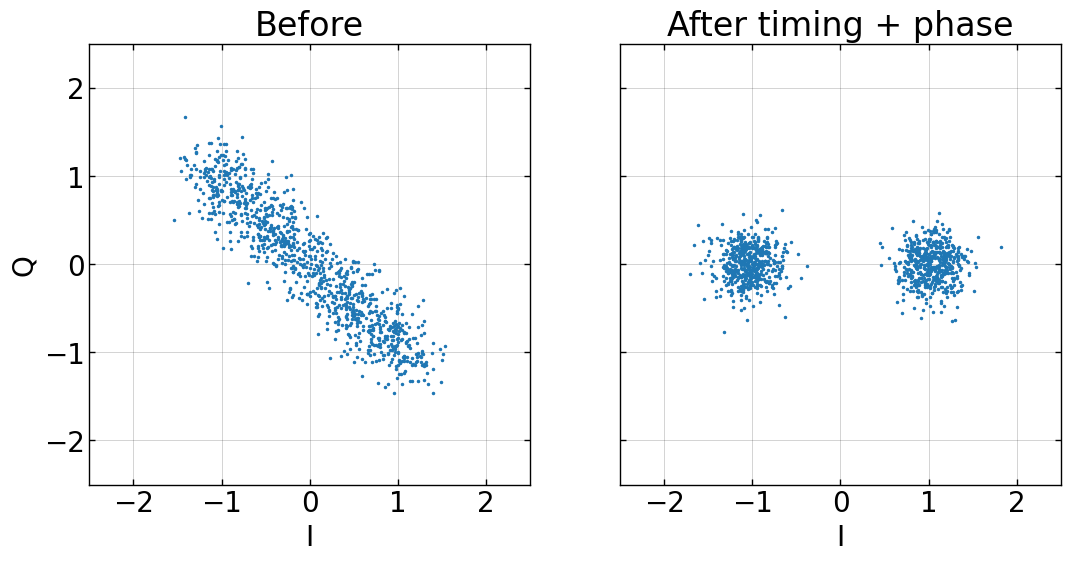

In [20]:
# coarse: the peak sample. fine: parabola through the peak and its neighbours
m0 = np.argmax(R_mag)
y_m, y_0, y_p = R_mag[m0 - 1], R_mag[m0], R_mag[(m0 + 1) % R_mag.size]
d_frac  = 0.5 * (y_m - y_p) / (y_m - 2 * y_0 + y_p)
tau_crs = m0 / fs_FPGA
tau_hat = (m0 + d_frac) / fs_FPGA
theta   = np.angle(R[m0])                                 # phase at the peak

# known fixed delay: the DAC pulse is centered half a DAC sample after its sample instant
# (on the analog grid: (OS - 1) / 2 grid points, i.e. 3.5 / 39.3 GHz = 89 ps)
D_FIXED = (OS - 1) / 2 / fs_grid
tau_crs -= D_FIXED
tau_hat -= D_FIXED

print(f"true delay     : {TAU * 1e9:10.4f} ns")
print(f"coarse estimate: {tau_crs * 1e9:10.4f} ns   error {(tau_crs - TAU) * 1e12:8.1f} ps = {(tau_crs - TAU) * C_LIGHT * 100:6.1f} cm")
print(f"fine estimate  : {tau_hat * 1e9:10.4f} ns   error {(tau_hat - TAU) * 1e12:8.1f} ps = {(tau_hat - TAU) * C_LIGHT * 100:6.1f} cm")
print(f"phase          : {np.degrees(theta):.1f} deg      (fixed DAC delay subtracted: {D_FIXED * 1e12:.1f} ps)")

# undo the delay (fractional advance in the frequency domain) and the phase, then sample at the chip instants
f_z    = np.fft.fftfreq(z_mf.size, 1 / fs_FPGA)
z_al   = np.fft.ifft(np.fft.fft(z_mf) * np.exp(2j * np.pi * f_z * (tau_hat + D_FIXED))) * np.exp(-1j * theta)
chip_y = z_al[::SPS_FPGA]                                  # one value per chip
errors = np.sum(np.sign(chip_y.real) != chips)
print(f"chip errors after timing + phase correction: {errors} / {chips.size}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5), layout='constrained', sharey=True)
ax[0].plot(z_mf.real[::SPS_FPGA], z_mf.imag[::SPS_FPGA], '.', ms=3)
ax[0].set(xlabel="I", ylabel="Q", title="Before", aspect="equal", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
ax[1].plot(chip_y.real, chip_y.imag, '.', ms=3)
ax[1].set(xlabel="I", title="After timing + phase", aspect="equal", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
for a in ax:
    a.grid(alpha=0.3)

# Performance

### 13. Timing precision vs SNR

Repeat the receive chain many times with fresh noise and look at the spread of the delay estimate. The function below is sections 7 to 12 in compact form, starting from the noise-free received signal `rx_clean`.

What to expect:
* At **low SNR** the error is set by noise and falls as the SNR rises (roughly by $\sqrt{10}$ per 10 dB).
* At **high SNR** it levels off at the bias of the parabolic fit (section 12), a few ps for this delay. That floor is a property of the interpolation method, not of the signal.
* Below some SNR the peak gets lost among the correlation noise and the error jumps by whole chips (an outlier). Thanks to the 30 dB processing gain this only happens far below 0 dB.

SNR  -25 dB: RMS error 10496853.3 ps = 314687.75 cm,  mean 8072977.0 ps


SNR  -20 dB: RMS error 3485131.5 ps = 104481.62 cm,  mean 760072.4 ps


SNR  -15 dB: RMS error    1212.8 ps =   36.36 cm,  mean    -41.0 ps


SNR  -10 dB: RMS error     681.6 ps =   20.43 cm,  mean    -52.3 ps


SNR   -5 dB: RMS error     398.6 ps =   11.95 cm,  mean    -40.7 ps


...

SNR   10 dB: RMS error      77.9 ps =    2.33 cm,  mean     -5.7 ps


SNR   15 dB: RMS error      31.5 ps =    0.95 cm,  mean      9.9 ps


SNR   20 dB: RMS error      18.1 ps =    0.54 cm,  mean     -0.1 ps


SNR   25 dB: RMS error      14.7 ps =    0.44 cm,  mean      5.4 ps


SNR   30 dB: RMS error       7.4 ps =    0.22 cm,  mean      5.1 ps


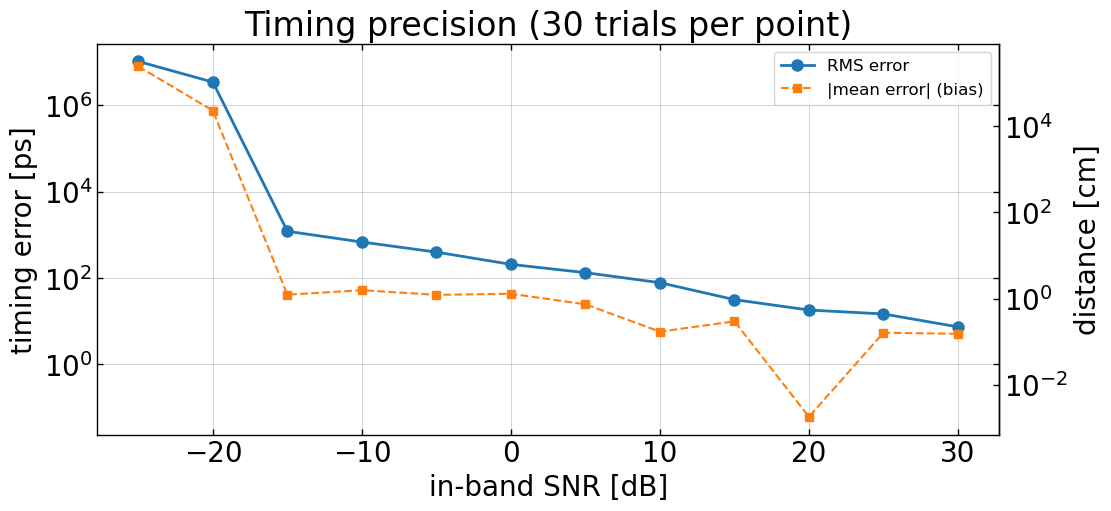

In [21]:
def estimate_tau(snr_db, rng):
    # noise -> RX BPF -> ADC -> NCO -> decimation -> matched filter -> correlation -> parabola
    s2  = P_sig / 10 ** (snr_db / 10) * fs_grid / (2 * B_SIG)
    x   = rx_clean + rng.normal(0, np.sqrt(s2), rx_clean.size)
    x   = np.fft.irfft(np.fft.rfft(x) * H_bpf, x.size)[::OS_ADC]
    zz  = matched_filter(lowpass_decimate(x * lo_rx))
    Rm  = np.abs(np.fft.ifft(np.fft.fft(zz) * np.conj(np.fft.fft(up))))
    k0  = np.argmax(Rm)
    ym, y0, yp = Rm[k0 - 1], Rm[k0], Rm[(k0 + 1) % Rm.size]
    return (k0 + 0.5 * (ym - yp) / (ym - 2 * y0 + yp)) / fs_FPGA - D_FIXED

SNR_LIST = np.arange(-25, 31, 5)       # in-band SNR [dB]
N_TRIALS = 30                          # noise realizations per SNR
rng_mc   = np.random.default_rng(2)

rms_ps, bias_ps = [], []
for snr in SNR_LIST:
    err = np.array([estimate_tau(snr, rng_mc) - TAU for _ in range(N_TRIALS)])
    rms_ps.append(np.sqrt(np.mean(err ** 2)) * 1e12)
    bias_ps.append(np.mean(err) * 1e12)
    print(f"SNR {snr:4d} dB: RMS error {rms_ps[-1]:9.1f} ps = {rms_ps[-1] * 1e-12 * C_LIGHT * 100:7.2f} cm,"
          f"  mean {bias_ps[-1]:8.1f} ps")

fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
ax.semilogy(SNR_LIST, rms_ps, 'o-', lw=2, ms=8, label="RMS error")
ax.semilogy(SNR_LIST, np.abs(bias_ps), 's--', lw=1.5, ms=6, label="|mean error| (bias)")
ax.set(xlabel="in-band SNR [dB]", ylabel="timing error [ps]", title=f"Timing precision ({N_TRIALS} trials per point)")
sec = ax.secondary_yaxis("right", functions=(lambda ps: ps * 1e-12 * C_LIGHT * 100, lambda cm: cm / (1e-12 * C_LIGHT * 100)))
sec.set_ylabel("distance [cm]")
ax.legend(fontsize=12); ax.grid(alpha=0.3, which="both")